# **Grupo 10 - Aprendizagem Não supervisionada**
## **Nomes:**
- Larissa Akemi Iuki
- Marcos Vinicuis Suguino
- Luan Fernandes de França

## **Informação do conjunto de dados**

Breast Cancer Wisconsin (Diagnostic): Esse dataset contém medições extraídas de imagens de aspiração por agulha fina (FNA) de massas mamárias. A ideia é realizar a detecção de anomalias, ou seja, prever se o tumor não é Benigno (B).

**Estrutura do dataset**

* Instâncias: 569 amostras
* Features: 30 variáveis numéricas contínuas
* Target: diagnosis (B ou M) - O Target não será utilizado no treinamento

Link: https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

# Carregando o dataset

In [173]:
%pip install ucimlrepo
%matplotlib inline

In [234]:
import plotly.io as pio

# fallback de renderer (evita erro fora do Colab)
available = set(pio.renderers)
if "colab" in available:
    pio.renderers.default = "colab"
elif "notebook_connected" in available:
    pio.renderers.default = "notebook_connected"
else:
    pio.renderers.default = "plotly_mimetype"

In [174]:
from ucimlrepo import fetch_ucirepo

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline
pio.renderers.default = "colab"  # alternativa: "notebook_connected"

RANDOM_SEED = 33
np.random.seed(RANDOM_SEED)

# ============================================================
# Carregando os dados
# ============================================================

# fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

# data (as pandas dataframes)
X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets

# Mapeando targets: M (Malignant) -> 1, B (Benign) -> 0
y = y['Diagnosis'].map({'M': 1, 'B': 0})

# metadata
print(breast_cancer_wisconsin_diagnostic.metadata)

# variable information
print(breast_cancer_wisconsin_diagnostic.variables)

{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1

In [175]:
print("Shape de X:", X.shape)
print("Shape de y:", y.shape)
print("Distribuição de y:\n", y.value_counts())

Shape de X: (569, 30)
Shape de y: (569,)
Distribuição de y:
 Diagnosis
0    357
1    212
Name: count, dtype: int64


In [176]:
# ============================================================
# Limpando os dados
# ============================================================

# Combinando X e y para facilitar a limpeza
df = X.copy()
df['Label'] = y

# --- Registros duplicados ---
initial_len = df.shape[0]
df = df.drop_duplicates()
print(f'\nDuplicadas: Tamanho inicial {initial_len} → final {df.shape[0]} | Descartadas: {initial_len - df.shape[0]}')

# --- Valores NaN/Null/NA ---
initial_len = df.shape[0]
df = df.dropna()
print(f'NaN/NA: Tamanho inicial {initial_len} → final {df.shape[0]} | Descartados: {initial_len - df.shape[0]}')

df = df.reset_index(drop=True)

# --- Valores não finitos ---
numeric_cols = df.drop('Label', axis='columns').columns
for col in numeric_cols:
    max_finite = df[np.isfinite(df[col])][col].max()
    min_finite = df[np.isfinite(df[col])][col].min()
    df.loc[df[col] == np.inf,  col] = max_finite
    df.loc[df[col] == -np.inf, col] = min_finite

# Separando novamente X e y após limpeza
X_clean = df.drop('Label', axis='columns')
y_clean = df['Label']


Duplicadas: Tamanho inicial 569 → final 569 | Descartadas: 0
NaN/NA: Tamanho inicial 569 → final 569 | Descartados: 0


# Mini análise exploratória - Parte 1

In [177]:
# ============================================================
# Mini Análise Exploratória - Parte 1
# ============================================================

# Adicionando coluna de label legível para visualização
df_viz = X_clean.copy()
df_viz['Label'] = y_clean.map({0: 'Benign', 1: 'Malignant'})

# --- Quantidade de instâncias benignas x malignas ---
fig = px.histogram(
    df_viz, x='Label', color='Label',
    title='Contagem de amostras por classe binária',
    color_discrete_map={
        'Benign':    px.colors.qualitative.Plotly[0],
        'Malignant': px.colors.qualitative.Plotly[1]
    }
)
fig.show()

# --- Estatísticas descritivas das features de média ---
interesting_cols = ['radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1']
print("Estatísticas descritivas (features de média):")
print(df_viz[interesting_cols].describe().round(4))

# --- Boxplots das principais features por classe ---
features_box = ['radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1', 'compactness1']

fig_box = make_subplots(rows=2, cols=3, subplot_titles=features_box)

for i, feat in enumerate(features_box):
    row, col = divmod(i, 3)
    for label, color in [('Benign',    px.colors.qualitative.Plotly[0]),
                          ('Malignant', px.colors.qualitative.Plotly[1])]:
        fig_box.add_trace(
            go.Box(
                y=df_viz[df_viz['Label'] == label][feat],
                name=label,
                marker_color=color,
                showlegend=(i == 0)
            ),
            row=row+1, col=col+1
        )

fig_box.update_layout(
    height=600,
    title_text='Boxplot das principais features (média) por classe',
    boxmode='group'
)
fig_box.show()

# --- Histogramas sobrepostos por classe ---
fig_hist = make_subplots(rows=2, cols=3, subplot_titles=features_box)

for i, feat in enumerate(features_box):
    row, col = divmod(i, 3)
    for label, color in [('Benign',    px.colors.qualitative.Plotly[0]),
                          ('Malignant', px.colors.qualitative.Plotly[1])]:
        fig_hist.add_trace(
            go.Histogram(
                x=df_viz[df_viz['Label'] == label][feat],
                name=label,
                opacity=0.6,
                marker_color=color,
                showlegend=(i == 0)
            ),
            row=row+1, col=col+1
        )

fig_hist.update_layout(
    barmode='overlay',
    height=600,
    title_text='Distribuição das principais features (média) por classe'
)
fig_hist.show()

# --- Repetindo para features de erro padrão (sufixo 2) ---
features_se = ['radius2', 'texture2', 'perimeter2', 'area2', 'smoothness2', 'compactness2']

fig_se = make_subplots(rows=2, cols=3, subplot_titles=features_se)

for i, feat in enumerate(features_se):
    row, col = divmod(i, 3)
    for label, color in [('Benign',    px.colors.qualitative.Plotly[0]),
                          ('Malignant', px.colors.qualitative.Plotly[1])]:
        fig_se.add_trace(
            go.Box(
                y=df_viz[df_viz['Label'] == label][feat],
                name=label,
                marker_color=color,
                showlegend=(i == 0)
            ),
            row=row+1, col=col+1
        )

fig_se.update_layout(
    height=600,
    title_text='Boxplot das features de erro padrão por classe',
    boxmode='group'
)
fig_se.show()

# --- Repetindo para features do pior valor (sufixo 3) ---
features_worst = ['radius3', 'texture3', 'perimeter3', 'area3', 'smoothness3', 'compactness3']

fig_worst = make_subplots(rows=2, cols=3, subplot_titles=features_worst)

for i, feat in enumerate(features_worst):
    row, col = divmod(i, 3)
    for label, color in [('Benign',    px.colors.qualitative.Plotly[0]),
                          ('Malignant', px.colors.qualitative.Plotly[1])]:
        fig_worst.add_trace(
            go.Box(
                y=df_viz[df_viz['Label'] == label][feat],
                name=label,
                marker_color=color,
                showlegend=(i == 0)
            ),
            row=row+1, col=col+1
        )

fig_worst.update_layout(
    height=600,
    title_text='Boxplot das features do pior valor por classe',
    boxmode='group'
)
fig_worst.show()

Estatísticas descritivas (features de média):
        radius1  texture1  perimeter1      area1  smoothness1
count  569.0000  569.0000     569.000   569.0000     569.0000
mean    14.1273   19.2896      91.969   654.8891       0.0964
std      3.5240    4.3010      24.299   351.9141       0.0141
min      6.9810    9.7100      43.790   143.5000       0.0526
25%     11.7000   16.1700      75.170   420.3000       0.0864
50%     13.3700   18.8400      86.240   551.1000       0.0959
75%     15.7800   21.8000     104.100   782.7000       0.1053
max     28.1100   39.2800     188.500  2501.0000       0.1634


Estatísticas dos dados

In [178]:
X_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
radius1,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture1,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter1,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area1,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness1,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness1,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity1,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave_points1,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry1,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
fractal_dimension1,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


# Dividindo dados nos conjuntos de treino, validação e teste

**Conjunto de treino**

Para a detecção de anomalias, vamos usar somente os dados que representam o tumor benigno para o conjunto de treino. Dessa forma, os algoritmos de clustering vão ser capazes de identificar padrões e desvios em relação ao comportamento normal (benigno) dos dados.

**Conjuntos de validação e teste**

Porém, devem ser incluídos dados que representam o tumores maliciosos nos conjuntos de validação e teste. Esses dados maliciosos no conjunto de validação são importantes para que possamos definir um *threshold* para que seja possível detectar anomalias. Além disso, os dados maliciosos também precisam ser incluídos no conjunto de teste para que possamos avaliar o desempenho do nosso modelo.

In [179]:
# ============================================================
# Dividindo dados: treino apenas com benignas
# ============================================================

df_train = df_viz.query('Label == "Benign"').sample(frac=0.6, random_state=RANDOM_SEED)
df_val_test = df_viz.drop(df_train.index)

df_train = df_train.reset_index(drop=True)
df_val_test = df_val_test.reset_index(drop=True)

X_train = df_train.drop('Label', axis='columns')

In [180]:
X_val, X_test, classes_val, classes_test = train_test_split(df_val_test.drop('Label', axis='columns'), df_val_test['Label'], test_size=0.65, stratify=df_val_test['Label'], random_state=RANDOM_SEED)

X_val, X_test = X_val.reset_index(drop=True), X_test.reset_index(drop=True)
classes_val, classes_test =  classes_val.reset_index(drop=True), classes_test.reset_index(drop=True)

y_val, y_test = classes_val.apply(lambda c: 0 if c == 'Benign' else 1), classes_test.apply(lambda c: 0 if c == 'Benign' else 1)

# Mini Análise Exploratória - Parte 2

In [181]:
# Preparando df_val com coluna auxiliar de classe binária
df_val = X_val.copy()
df_val['Label'] = classes_val  # 'Malignant' ou 'Benign'
df_val['isMalignant'] = df_val['Label'].apply(lambda l: 1 if l == 'Malignant' else 0)

In [182]:
# -------------------------------------------------------------
# 1. Boxplot: Raio médio (radius1) por diagnóstico
# Aqui verificamos se o raio médio do núcleo celular distingue
# tumores malignos de benignos.
# -------------------------------------------------------------
px.box(
    df_val,
    x='radius1',
    y='Label',
    color='Label',
    color_discrete_map={'Benign': px.colors.qualitative.Plotly[0],
                        'Malignant': px.colors.qualitative.Plotly[1]},
    title='Boxplot do Raio Médio (radius1) por Diagnóstico'
)

In [183]:
# -------------------------------------------------------------
# 2. Boxplot: Concavidade média (concavity1) por diagnóstico
# Tumores malignos tendem a ter bordas mais irregulares/côncavas.
# -------------------------------------------------------------
px.box(
    df_val,
    x='concavity1',
    y='Label',
    color='Label',
    color_discrete_map={'Benign': px.colors.qualitative.Plotly[0],
                        'Malignant': px.colors.qualitative.Plotly[1]},
    title='Boxplot da Concavidade Média (concavity1) por Diagnóstico'
)


In [184]:
# -------------------------------------------------------------
# 3. Top 10 features com maior correlação com o diagnóstico
# Como temos apenas 2 classes, calculamos a correlação global
# com a coluna 'isMalignant'.
# -------------------------------------------------------------
corr_with_label = df_val.drop(['Label'], axis='columns').corr()['isMalignant']

# Selecionando top 10 em módulo (excluindo a própria coluna alvo)
top10_idx = corr_with_label.abs().nlargest(11).index
top10_corr = corr_with_label[top10_idx].drop('isMalignant')

fig = go.Figure(
    go.Bar(
        x=top10_corr.index,
        y=top10_corr.values,
        marker_color=[
            px.colors.qualitative.Plotly[1] if v > 0 else px.colors.qualitative.Plotly[0]
            for v in top10_corr.values
        ]
    )
)
fig.update_layout(
    title='Top 10 Features com Maior Correlação (em módulo) com o Diagnóstico',
    xaxis_title='Feature',
    yaxis_title='Correlação com isMalignant',
    xaxis_tickangle=15
)
fig.show()


In [185]:
# -------------------------------------------------------------
# 4. Análise por grupo de features (mean / se / worst)
# O dataset tem 3 grupos de medições: média (_1), erro padrão (_2)
# e pior valor (_3). Verificamos qual grupo é mais correlacionado.
# -------------------------------------------------------------
groups = {
    'Média (_1)':  [c for c in X_val.columns if c.endswith('1')],
    'Erro Padrão (_2)': [c for c in X_val.columns if c.endswith('2')],
    'Pior Valor (_3)': [c for c in X_val.columns if c.endswith('3')],
}

fig = make_subplots(
    rows=3, cols=1,
    subplot_titles=list(groups.keys())
)

for i, (group_name, group_cols) in enumerate(groups.items()):
    available_cols = [c for c in group_cols if c in df_val.columns]
    curr_corr = df_val[available_cols + ['isMalignant']].corr()['isMalignant'].drop('isMalignant')
    curr_corr_sorted = curr_corr.abs().sort_values(ascending=False)

    fig.add_trace(
        go.Bar(
            x=curr_corr_sorted.index,
            y=curr_corr[curr_corr_sorted.index].values,
            name=group_name,
            marker_color=[
                px.colors.qualitative.Plotly[1] if v > 0 else px.colors.qualitative.Plotly[0]
                for v in curr_corr[curr_corr_sorted.index].values
            ]
        ),
        row=i+1, col=1
    )
    fig.update_xaxes(tickangle=15, row=i+1, col=1)

fig.update_layout(
    height=900,
    width=1200,
    title_text='Correlação com Diagnóstico por Grupo de Features'
)
fig.show()

# -------------------------------------------------------------
# Limpeza
# -------------------------------------------------------------
del df_val

# Analisando correlação entre features

In [186]:
corr = X_train.corr()

# pares altamente correlacionados
strong_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
         .stack()
         .sort_values(ascending=False)
)

print(strong_pairs.head(20))

radius1       perimeter1    0.996699
              area1         0.993976
radius3       area3         0.992762
perimeter1    area1         0.989913
radius3       perimeter3    0.982378
area1         area3         0.976845
radius1       radius3       0.975782
perimeter3    area3         0.974941
area1         radius3       0.973421
perimeter1    radius3       0.972535
radius1       area3         0.967816
perimeter1    perimeter3    0.965079
              area3         0.963626
radius1       perimeter3    0.958157
area1         perimeter3    0.953499
texture1      texture3      0.932525
radius2       area2         0.916591
concavity1    concavity2    0.915023
radius2       perimeter2    0.898947
compactness3  concavity3    0.876444
dtype: float64


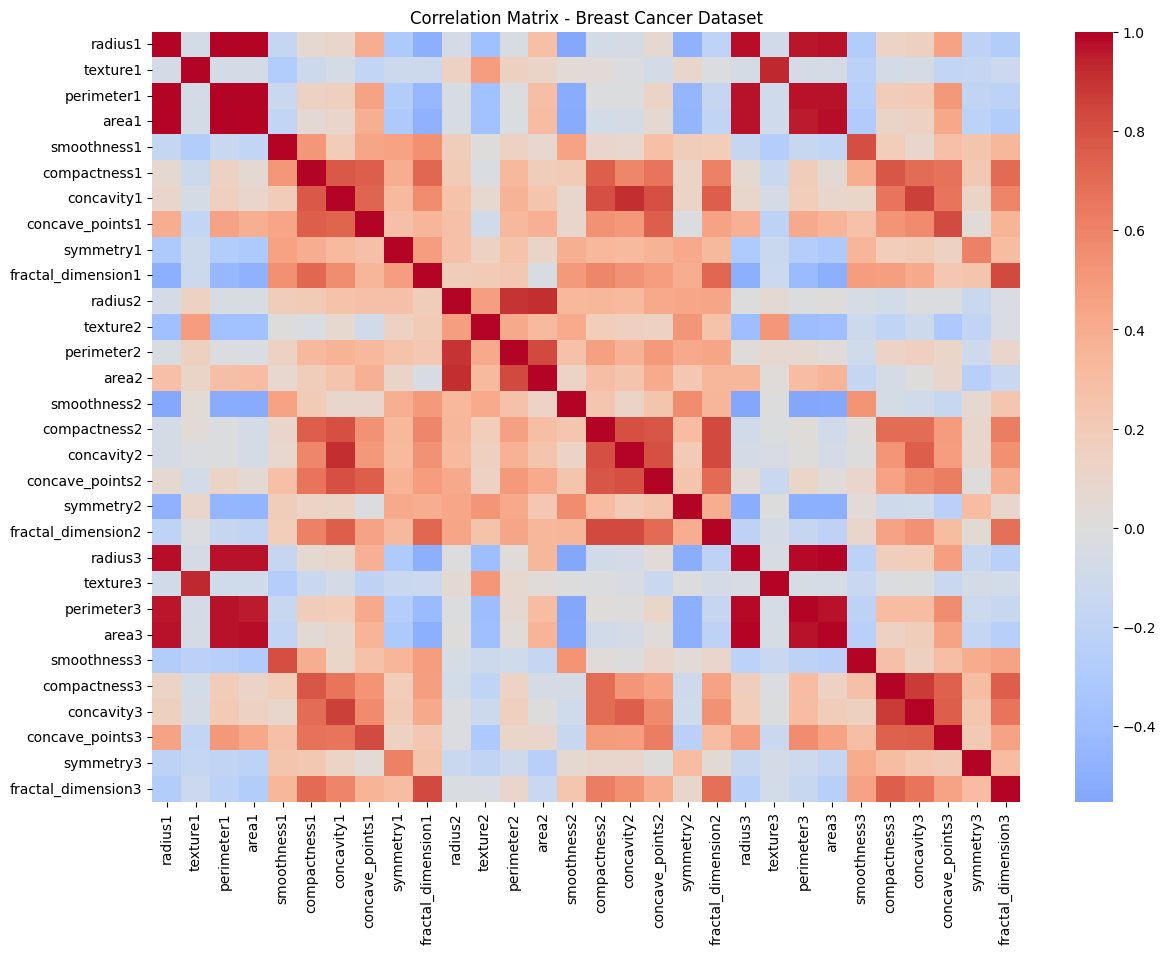

In [187]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,10))
sns.heatmap(X_train.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Matrix - Breast Cancer Dataset")
plt.show()

## Removendo features redundantes

**Por que remover features?**

Vamos descartar features com alta correlação evitando passar informações redundantes ao modelo. Dessa forma, conseguiremos obter um modelo mais simples e com menor custo computacional.

In [188]:
def get_highly_correlated_features(correlation_matrix, threshold):
  correlated_pairs = []
  for i in range(len(correlation_matrix.columns)):
    for j in range(i):
      if abs(correlation_matrix.iloc[i, j]) > threshold:
        pair = (correlation_matrix.columns[i], correlation_matrix.columns[j])
        coefficient = correlation_matrix.iloc[i, j]
        correlated_pairs.append((pair, coefficient))
  return sorted(correlated_pairs, key= lambda pair: pair[1], reverse=True)

In [189]:
corr_matrix = X_train.corr().abs()
correlation_list = get_highly_correlated_features(corr_matrix, 0.95)

In [190]:
correlation_list[:10]

[(('perimeter1', 'radius1'), np.float64(0.9966986333085475)),
 (('area1', 'radius1'), np.float64(0.993975512608107)),
 (('area3', 'radius3'), np.float64(0.992761589983657)),
 (('area1', 'perimeter1'), np.float64(0.9899133330233807)),
 (('perimeter3', 'radius3'), np.float64(0.9823780270185722)),
 (('area3', 'area1'), np.float64(0.9768447725926166)),
 (('radius3', 'radius1'), np.float64(0.9757823064782337)),
 (('area3', 'perimeter3'), np.float64(0.9749412550845791)),
 (('radius3', 'area1'), np.float64(0.9734211521680601)),
 (('radius3', 'perimeter1'), np.float64(0.9725350505313176))]

In [191]:
# Drop high correlated features in correlation list

f2drop = []
for feature_pair, _ in correlation_list:
  if feature_pair[0] not in f2drop and feature_pair[1] not in f2drop:
    f2drop.append(feature_pair[1])

In [192]:
f2drop

['radius1', 'radius3', 'perimeter1', 'area1', 'perimeter3']

In [193]:
X_train = X_train.drop(f2drop, axis='columns')
X_val = X_val.drop(f2drop, axis='columns')
X_test = X_test.drop(f2drop, axis='columns')

# Normalizando os dados

É importante normalizar os dados para lidar com diferentes escalas, sensibilidades a escalas e até mesmo melhorar o desempenho da convergência dos algoritmos.

Caso não seja realizada a normalização, um valor de 1000 para uma feature como "area1" terá impacto similar ao modelo quanto um valor de 1000 para uma feature como "radius1". Isso é prejudicial, pois o impacto desse valor para as duas features deve ser tratado de forma distinta, já que as mesmas têm escalas e sensibilidades também distintas.

In [194]:
# Usando MinMax Scaler dessa vez para que a rede neural seja capaz de gerar saídas no intervalo numérico da função sigmóide.

minmax_scaler = MinMaxScaler()
minmax_scaler = minmax_scaler.fit(X_train)

norm_X_train = minmax_scaler.transform(X_train)
norm_X_val = minmax_scaler.transform(X_val)
norm_X_test = minmax_scaler.transform(X_test)

# Detecção de Anomalias com o KMeans

In [195]:
from tqdm.notebook import tqdm
from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import confusion_matrix

from sklearn.decomposition import PCA

random_train_indexes = np.random.choice(norm_X_train.shape[0], int(norm_X_train.shape[0]*0.1), replace=False)
norm_X_train_subset = norm_X_train[random_train_indexes,:]

In [196]:
k_list = list(range(2, min(21, norm_X_train_subset.shape[0])))
silhouette_score_list = []
for k in tqdm(k_list):
    model_kmeans = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10)
    model_kmeans = model_kmeans.fit(norm_X_train_subset)
    s_score = silhouette_score(norm_X_train_subset, model_kmeans.predict(norm_X_train_subset))
    silhouette_score_list.append(s_score)

  0%|          | 0/19 [00:00<?, ?it/s]

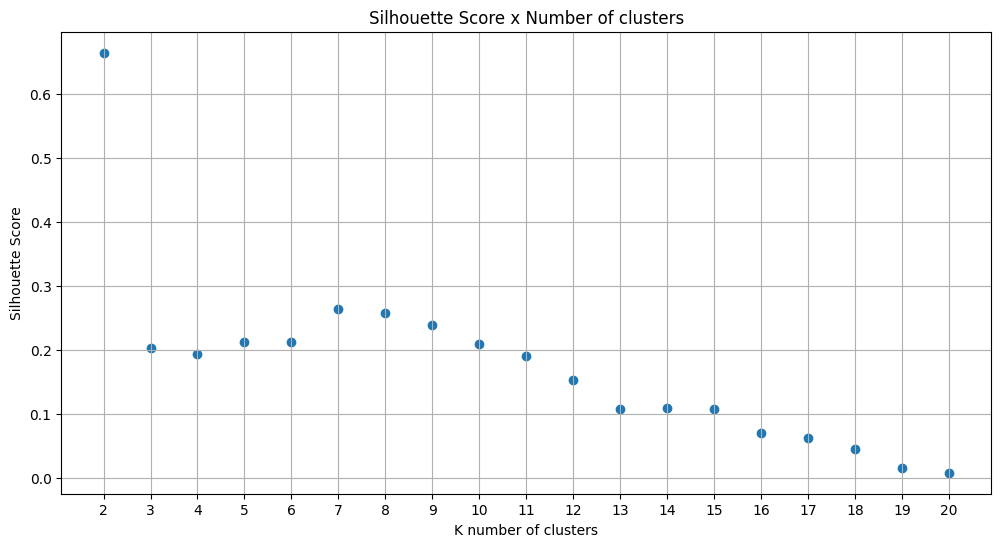

In [197]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlabel('K number of clusters')
ax.set_ylabel('Silhouette Score')
ax.set_xticks(k_list)
ax.set_title('Silhouette Score x Number of clusters')
ax.grid()
ax.scatter(k_list, silhouette_score_list)

In [198]:
K_CLUSTERS = 2

In [199]:
model_kmeans = KMeans(n_clusters=K_CLUSTERS, random_state=RANDOM_SEED, n_init=10)
model_kmeans = model_kmeans.fit(norm_X_train)

In [200]:
def plot_pca(X, model_kmeans=None, print_centroids = False):
  pca = PCA(n_components=2, random_state=RANDOM_SEED)
  X_pca = pca.fit_transform(X)

  fig, ax = plt.subplots(figsize=(14, 6))
  ax.set_title('PCA Analysis')

  if print_centroids and model_kmeans is not None:
    cluster_centers_principal_components = pca.transform(model_kmeans.cluster_centers_)
    num_clusters = cluster_centers_principal_components.shape[0]

    X_clusters = model_kmeans.predict(X)

    # For each cluster, plot their respective X data instances
    for cluster in range(num_clusters):
      indexes = np.where(X_clusters == cluster)
      if X_pca[indexes,:].shape[1] == 3:
        print(indexes)
      print(X_pca[indexes,:].shape)
      ax.scatter(X_pca[indexes, 0], X_pca[indexes, 1], s=1, c=plt.cm.tab20(cluster), label=f'Cluster#{cluster}')

    # For each cluster centroid, plot the centroid
    for i, cluster_center_pc in enumerate(cluster_centers_principal_components):
      ax.scatter(cluster_center_pc[0], cluster_center_pc[1], c='black', s=8, marker='x')
      ax.annotate(f'Cluster#{i}', (cluster_center_pc[0], cluster_center_pc[1]), size=10)
    ax.legend()

  else:
    ax.scatter(X_pca[:,0], X_pca[:,1], s=1)

(1, 145, 2)
(1, 69, 2)


/tmp/ipykernel_8962/415288942.py:20: UserWarning:

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.



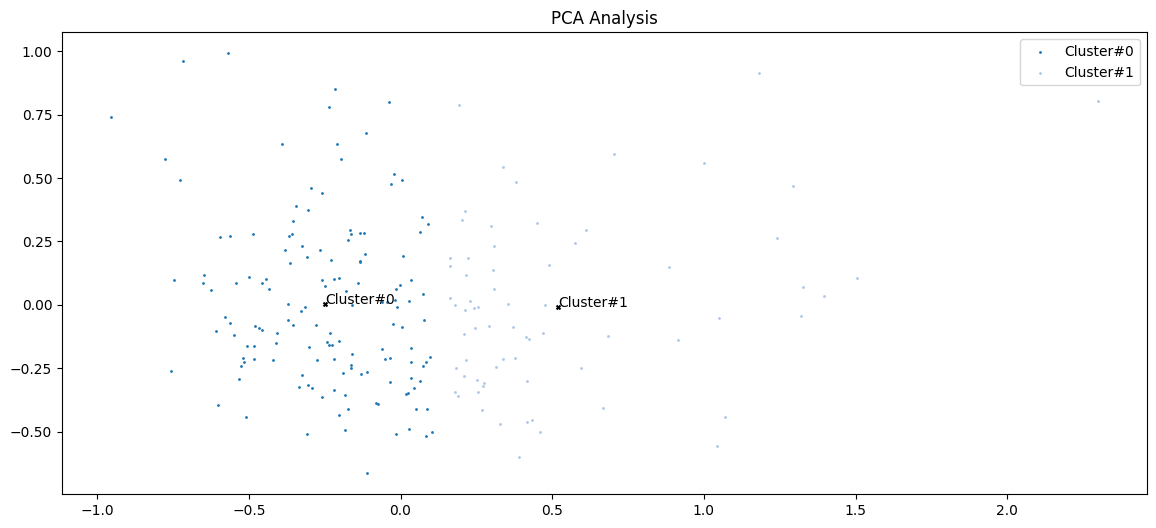

In [201]:
plot_pca(norm_X_train, model_kmeans, print_centroids=True)

# Definindo um threshold e avaliando resultados

In [202]:
# ...existing code...
def plot_roc_curve(y_true, y_score, max_fpr=1.0):
  fpr, tpr, thresholds = roc_curve(y_true, y_score)
  aucroc = roc_auc_score(y_true, y_score)

  plt.figure(figsize=(7, 5))
  mask = fpr < max_fpr
  plt.plot(
      100 * fpr[mask],
      100 * tpr[mask],
      label=f'ROC Curve (AUC = {aucroc:.4f})'
  )
  plt.xlim(-2, 102)
  plt.ylim(-2, 102)
  plt.xlabel('FPR (%)')
  plt.ylabel('TPR (%)')
  plt.legend(loc='lower right')
  plt.title('ROC Curve and AUCROC')
  plt.tight_layout()
  plt.show()
# ...existing code...

In [203]:
def get_overall_metrics(y_true, y_pred):
  tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
  acc = (tp+tn)/(tp+tn+fp+fn)
  tpr = tp/(tp+fn)
  fpr = fp/(fp+tn)
  precision = tp/(tp+fp)
  f1 = (2*tpr*precision)/(tpr+precision)
  return {'acc':acc,'tpr':tpr,'fpr':fpr,'precision':precision,'f1-score':f1}

In [204]:
# ...existing code...
def plot_confusion_matrix(y_true, y_pred):
  cm = confusion_matrix(y_true, y_pred)
  group_counts = [f'{value:.0f}' for value in cm.ravel()]
  group_percentages = [f'{value*100:.2f}%' for value in cm.ravel()/np.sum(cm)]
  labels = [f'{v1}\n{v2}' for v1, v2 in zip(group_counts, group_percentages)]
  labels = np.array(labels).reshape(2,2)

  plt.figure(figsize=(6, 5))
  sns.heatmap(
      cm, annot=labels, cmap='Oranges', fmt='',
      xticklabels=['Predicted Benign', 'Predicted Malignant'],
      yticklabels=['Actual Benign', 'Actual Malignant']
  )
  plt.tight_layout()
  plt.show()
# ...existing code...

In [205]:
val_centroids_distances = model_kmeans.transform(norm_X_val)
val_anomaly_scores = np.min(val_centroids_distances, axis=1)

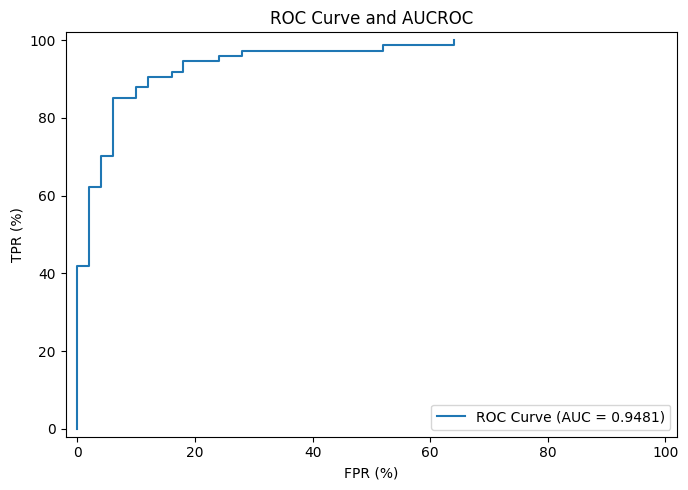

In [206]:
plot_roc_curve(y_val, val_anomaly_scores)

## Escolha do threshold

In [207]:
fpr, tpr, thresholds = roc_curve(y_val, val_anomaly_scores)
df_val_roc = pd.DataFrame({'fpr':fpr, 'tpr':tpr, 'thresholds':thresholds})
df_val_roc['youden-index'] = df_val_roc['tpr'] - df_val_roc['fpr']
df_val_roc.sort_values('youden-index', ascending=False).drop_duplicates('fpr')

,fpr,tpr,thresholds,youden-index
8,0.06,0.851351,0.963865,0.791351
12,0.12,0.905405,0.878620,0.785405
10,0.10,0.878378,0.910878,0.778378
16,0.18,0.945946,0.826449,0.765946
14,0.16,0.918919,0.851232,0.758919
18,0.24,0.959459,0.767365,0.719459
20,0.28,0.972973,0.723255,0.692973
6,0.04,0.702703,1.141168,0.662703
4,0.02,0.621622,1.377904,0.601622
22,0.52,0.986486,0.609350,0.466486


In [208]:
BEST_VALIDATION_THRESHOLD = 0.963865

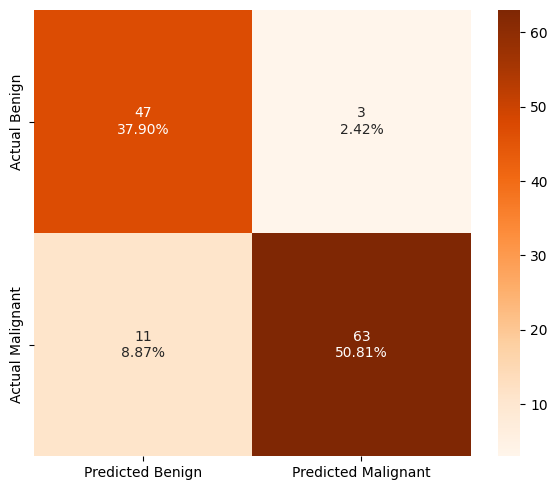

In [209]:
plot_confusion_matrix(y_val, val_anomaly_scores > BEST_VALIDATION_THRESHOLD)

In [210]:
get_overall_metrics(y_val, val_anomaly_scores > BEST_VALIDATION_THRESHOLD)

{'acc': np.float64(0.8870967741935484),
 'tpr': np.float64(0.8513513513513513),
 'fpr': np.float64(0.06),
 'precision': np.float64(0.9545454545454546),
 'f1-score': np.float64(0.9)}

## Conjunto de teste

In [211]:
test_centroids_distances = model_kmeans.transform(norm_X_test)
test_anomaly_scores = np.min(test_centroids_distances, axis=1)

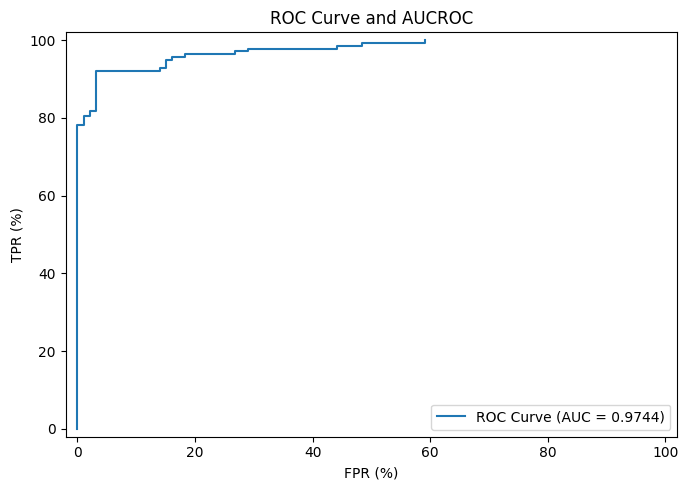

In [212]:
plot_roc_curve(y_test, test_anomaly_scores)

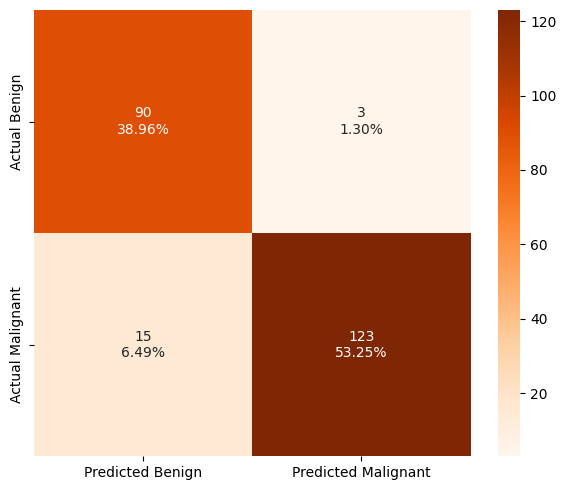

In [213]:
plot_confusion_matrix(y_test, test_anomaly_scores > BEST_VALIDATION_THRESHOLD)

In [214]:
get_overall_metrics(y_test, test_anomaly_scores > BEST_VALIDATION_THRESHOLD)

{'acc': np.float64(0.922077922077922),
 'tpr': np.float64(0.8913043478260869),
 'fpr': np.float64(0.03225806451612903),
 'precision': np.float64(0.9761904761904762),
 'f1-score': np.float64(0.9318181818181818)}

# Detecção de Anomalias com o Isolation Forest

In [215]:
# ============================================================
# Grid Search de hiperparâmetros no conjunto de validação
# busca os melhores hiperparâmetros otimizando AUC-ROC
# ============================================================

from sklearn.ensemble import IsolationForest

best_auc    = 0
best_params = {}
best_model  = None

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_features': [0.5, 0.75, 1.0],
    'max_samples':  ['auto', 0.5, 0.8],
}

for n_est in tqdm(param_grid['n_estimators'], desc='n_estimators'):
    for max_feat in param_grid['max_features']:
        for max_samp in param_grid['max_samples']:
            m = IsolationForest(
                n_estimators=n_est,
                max_features=max_feat,
                max_samples=max_samp,
                random_state=RANDOM_SEED
            ).fit(norm_X_train)

            # Usando decision_function em vez de predict
            # decision_function retorna score contínuo; negamos para que
            # valores maiores indiquem maior chance de anomalia
            scores = -m.decision_function(norm_X_val)
            auc    = roc_auc_score(y_val, scores)

            if auc > best_auc:
                best_auc    = auc
                best_params = {
                    'n_estimators': n_est,
                    'max_features': max_feat,
                    'max_samples':  max_samp,
                }
                best_model = m

print(f"\nMelhor AUC na validação : {best_auc:.4f}")
print(f"Melhores hiperparâmetros: {best_params}")

n_estimators:   0%|          | 0/3 [00:00<?, ?it/s]


Melhor AUC na validação : 0.9465
Melhores hiperparâmetros: {'n_estimators': 200, 'max_features': 0.75, 'max_samples': 'auto'}


In [216]:
# ============================================================
# Usando o melhor modelo encontrado
# model_iforest agora é o melhor modelo do grid search
# ============================================================
model_iforest = best_model

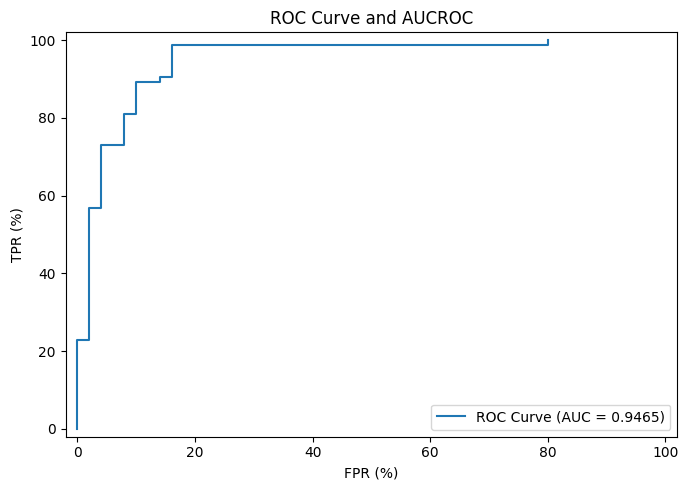

In [217]:
# ============================================================
# Curva ROC no conjunto de validação
# Antes: o código pulava direto para a predição binária com predict()
# ============================================================
val_scores_iforest = -model_iforest.decision_function(norm_X_val)

plot_roc_curve(y_val, val_scores_iforest)

In [218]:
# ============================================================
# Escolha do threshold pelo índice de Youden (como no KMeans)
# otimiza o threshold via curva ROC no conjunto de validação
# ============================================================
fpr_if, tpr_if, thresholds_if = roc_curve(y_val, val_scores_iforest)

df_val_roc_if = pd.DataFrame({
    'fpr':        fpr_if,
    'tpr':        tpr_if,
    'thresholds': thresholds_if
})
df_val_roc_if['youden-index'] = df_val_roc_if['tpr'] - df_val_roc_if['fpr']

best_row_if = df_val_roc_if.loc[df_val_roc_if['youden-index'].idxmax()]
BEST_THRESHOLD_IFOREST = best_row_if['thresholds']

print(f"\nMelhor threshold (Youden): {BEST_THRESHOLD_IFOREST:.6f}")
print(f"  TPR esperado: {best_row_if['tpr']:.4f}")
print(f"  FPR esperado: {best_row_if['fpr']:.4f}")


Melhor threshold (Youden): -0.047703
  TPR esperado: 0.9865
  FPR esperado: 0.1600



--- Validação ---


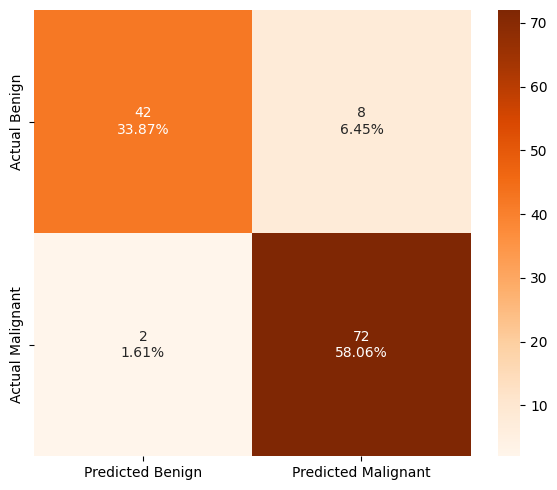

{'acc': np.float64(0.9193548387096774), 'tpr': np.float64(0.972972972972973), 'fpr': np.float64(0.16), 'precision': np.float64(0.9), 'f1-score': np.float64(0.935064935064935)}


In [219]:
# ============================================================
# Avaliação na validação com threshold otimizado
# score contínuo comparado ao threshold escolhido pelo índice de Youden
# ============================================================
print("\n--- Validação ---")
plot_confusion_matrix(y_val, val_scores_iforest > BEST_THRESHOLD_IFOREST)
print(get_overall_metrics(y_val, val_scores_iforest > BEST_THRESHOLD_IFOREST))


--- Teste ---


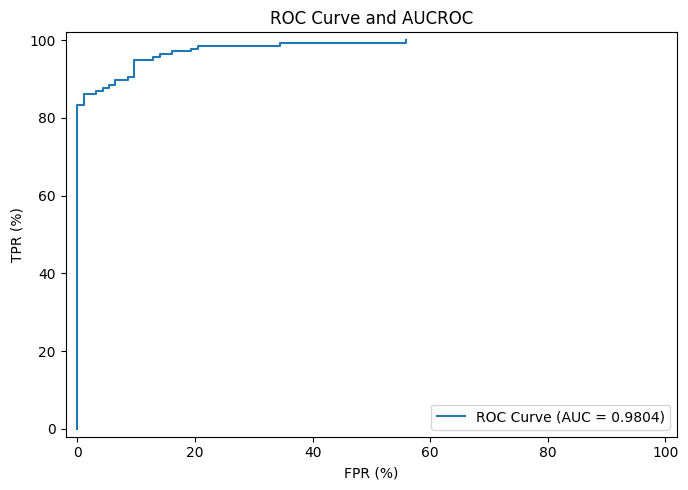

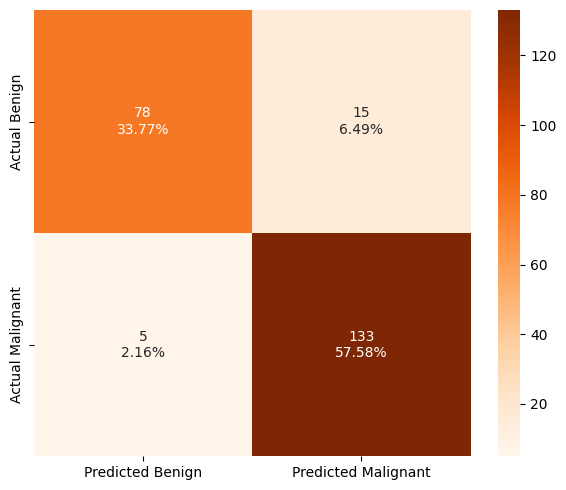

{'acc': np.float64(0.9134199134199135), 'tpr': np.float64(0.9637681159420289), 'fpr': np.float64(0.16129032258064516), 'precision': np.float64(0.8986486486486487), 'f1-score': np.float64(0.9300699300699301)}


In [220]:
# ============================================================
# Conjunto de teste
# mesmo pipeline de score contínuo + threshold otimizado na validação
# ============================================================
test_scores_iforest = -model_iforest.decision_function(norm_X_test)

print("\n--- Teste ---")
plot_roc_curve(y_test, test_scores_iforest)
plot_confusion_matrix(y_test, test_scores_iforest > BEST_THRESHOLD_IFOREST)
print(get_overall_metrics(y_test, test_scores_iforest > BEST_THRESHOLD_IFOREST))


# Detecção de Anomalias com GAN

In [221]:
# ...existing code...
# ============================================================
# GAN - 1) Imports e configuração
# ============================================================
import torch
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(RANDOM_SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Dados (somente benignos no treino)
X_train_tensor = torch.tensor(norm_X_train, dtype=torch.float32)

data_dim = norm_X_train.shape[1]
latent_dim = 16
batch_size = 32
epochs = 150
lr = 2e-4

Device: cpu


In [222]:
# ============================================================
# GAN - 2) Modelos
# ============================================================
class Discriminator(nn.Module):
    def __init__(self, tab_data_dim, lrelu_slope=0.1):
        super().__init__()

        self.disc = nn.Sequential(
            nn.Linear(tab_data_dim, 120),
            nn.LeakyReLU(lrelu_slope),
            nn.Linear(120, 80),
            nn.LeakyReLU(lrelu_slope),
            nn.Linear(80, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.disc(x)


class Generator(nn.Module):
    def __init__(self, z_dim, tab_data_dim, lrelu_slope=0.1):
        super().__init__()

        self.gen = nn.Sequential(
            nn.Linear(z_dim, 100),
            nn.LeakyReLU(lrelu_slope),
            nn.Linear(100, 80),
            nn.LeakyReLU(lrelu_slope),
            nn.Linear(80, tab_data_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.gen(x)


class GAN(nn.Module):
    def __init__(self, z_dim, tab_data_dim, lrelu_slope=0.1, device=None):
        super().__init__()

        self.device = device if device is not None else torch.device(
            "cuda" if torch.cuda.is_available() else "cpu"
        )

        self.z_dim = z_dim
        self.tab_data_dim = tab_data_dim
        self.lrelu_slope = lrelu_slope

        self.discriminator = Discriminator(
            self.tab_data_dim, self.lrelu_slope
        ).to(self.device)

        self.generator = Generator(
            self.z_dim, self.tab_data_dim, self.lrelu_slope
        ).to(self.device)

        self.optim_discriminator = None
        self.optim_generator = None
        self.criterion = None

    def compile(self, lr):
        self.optim_discriminator = optim.Adam(self.discriminator.parameters(), lr=lr)
        self.optim_generator = optim.Adam(self.generator.parameters(), lr=lr)
        self.criterion = nn.BCELoss()

    def fit(self, X, batch_size, num_epochs, X_val_np=None, y_val_np=None):
        assert self.optim_discriminator is not None
        assert self.optim_generator is not None
        assert self.criterion is not None

        g_losses, d_losses, val_auc_history = [], [], []
        best_val_auc = -np.inf
        best_disc_state = None

        for epoch in range(num_epochs):
            self.discriminator.train()
            self.generator.train()

            epoch_d_loss = 0.0
            epoch_g_loss = 0.0
            num_batches = 0

            perm = torch.randperm(len(X))
            X_epoch = X[perm]

            for batch in range(0, len(X_epoch), batch_size):
                real = X_epoch[batch:batch + batch_size]
                real = real.view(-1, self.tab_data_dim).to(self.device)
                curr_batch_size = real.shape[0]

                noise = torch.randn(curr_batch_size, self.z_dim, device=self.device)
                fake = self.generator(noise)

                discriminator_real_output = self.discriminator(real).view(-1)
                lossD_real = self.criterion(
                    discriminator_real_output,
                    torch.ones_like(discriminator_real_output)
                )

                discriminator_fake_output = self.discriminator(fake.detach()).view(-1)
                lossD_fake = self.criterion(
                    discriminator_fake_output,
                    torch.zeros_like(discriminator_fake_output)
                )

                lossD = (lossD_real + lossD_fake) / 2
                self.optim_discriminator.zero_grad()
                lossD.backward()
                self.optim_discriminator.step()

                noise = torch.randn(curr_batch_size, self.z_dim, device=self.device)
                fake = self.generator(noise)
                output = self.discriminator(fake).view(-1)

                lossG = self.criterion(output, torch.ones_like(output))
                self.optim_generator.zero_grad()
                lossG.backward()
                self.optim_generator.step()

                epoch_d_loss += lossD.item()
                epoch_g_loss += lossG.item()
                num_batches += 1

            d_losses.append(epoch_d_loss / num_batches)
            g_losses.append(epoch_g_loss / num_batches)

            if X_val_np is not None and y_val_np is not None:
                self.discriminator.eval()
                with torch.no_grad():
                    x_val = torch.tensor(X_val_np, dtype=torch.float32, device=self.device)
                    p_normal = self.discriminator(x_val).view(-1).cpu().numpy()
                    val_scores = 1.0 - p_normal

                current_val_auc = roc_auc_score(np.asarray(y_val_np), val_scores)
                val_auc_history.append(current_val_auc)

                if current_val_auc > best_val_auc:
                    best_val_auc = current_val_auc
                    best_disc_state = {
                        k: v.detach().cpu().clone()
                        for k, v in self.discriminator.state_dict().items()
                    }

                if (epoch + 1) % 25 == 0 or epoch == 0:
                    print(
                        f"Epoch [{epoch+1}/{num_epochs}] | "
                        f"D_loss: {d_losses[-1]:.4f} | "
                        f"G_loss: {g_losses[-1]:.4f} | "
                        f"Val AUC: {current_val_auc:.4f}"
                    )
            else:
                if (epoch + 1) % 25 == 0 or epoch == 0:
                    print(
                        f"Epoch [{epoch+1}/{num_epochs}] | "
                        f"D_loss: {d_losses[-1]:.4f} | G_loss: {g_losses[-1]:.4f}"
                    )

        if best_disc_state is not None:
            self.discriminator.load_state_dict(best_disc_state)
            self.discriminator.to(self.device)
            print(f"Melhor Val AUC carregada: {best_val_auc:.4f}")

        return g_losses, d_losses, val_auc_history

Epoch [1/150] | D_loss: 0.6850 | G_loss: 0.7799 | Val AUC: 0.5241
Epoch [25/150] | D_loss: 0.6808 | G_loss: 0.7425 | Val AUC: 0.9003
Epoch [50/150] | D_loss: 0.6133 | G_loss: 0.6993 | Val AUC: 0.0751
Epoch [75/150] | D_loss: 0.7273 | G_loss: 0.8365 | Val AUC: 0.6981
Epoch [100/150] | D_loss: 0.7662 | G_loss: 0.6353 | Val AUC: 0.4881
Epoch [125/150] | D_loss: 0.6339 | G_loss: 0.7772 | Val AUC: 0.0854
Epoch [150/150] | D_loss: 0.5651 | G_loss: 0.8886 | Val AUC: 0.9662
Melhor Val AUC carregada: 0.9705
Melhor AUC de validação durante o treino: 0.9705


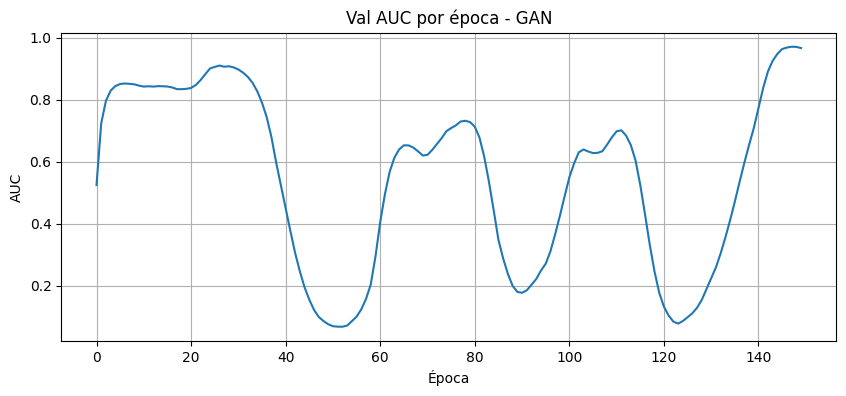

In [223]:
# ============================================================
# GAN - 3) Treinamento
# ============================================================
gan = GAN(
    z_dim=latent_dim,
    tab_data_dim=data_dim,
    lrelu_slope=0.1,
    device=device
)

gan.compile(lr=lr)
g_losses, d_losses, val_auc_history = gan.fit(
    X_train_tensor,
    batch_size=batch_size,
    num_epochs=epochs,
    X_val_np=norm_X_val,
    y_val_np=y_val
)

print(f"Melhor AUC de validação durante o treino: {max(val_auc_history):.4f}")

plt.figure(figsize=(10, 4))
plt.plot(val_auc_history)
plt.title("Val AUC por época - GAN")
plt.xlabel("Época")
plt.ylabel("AUC")
plt.grid(True)
plt.show()

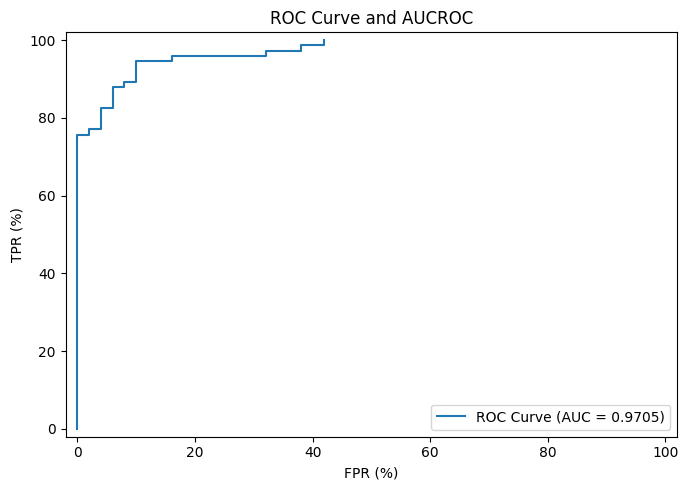


Melhor threshold GAN (Youden): 0.513329
TPR esperado: 0.9459
FPR esperado: 0.1000


In [224]:
# ============================================================
# GAN - 4) Score de anomalia + threshold
# ============================================================
def gan_anomaly_score(X_np, discriminator, device):
    discriminator.eval()
    with torch.no_grad():
        x = torch.tensor(X_np, dtype=torch.float32, device=device)
        p_normal = discriminator(x).view(-1).cpu().numpy()
    return 1.0 - p_normal


val_scores_gan = gan_anomaly_score(norm_X_val, gan.discriminator, device)
test_scores_gan = gan_anomaly_score(norm_X_test, gan.discriminator, device)

plot_roc_curve(y_val, val_scores_gan)

fpr_gan, tpr_gan, thresholds_gan = roc_curve(y_val, val_scores_gan)
df_val_roc_gan = pd.DataFrame({
    "fpr": fpr_gan,
    "tpr": tpr_gan,
    "thresholds": thresholds_gan
})
df_val_roc_gan["youden-index"] = df_val_roc_gan["tpr"] - df_val_roc_gan["fpr"]

best_row_gan = df_val_roc_gan.loc[df_val_roc_gan["youden-index"].idxmax()]
BEST_THRESHOLD_GAN = best_row_gan["thresholds"]

print(f"\nMelhor threshold GAN (Youden): {BEST_THRESHOLD_GAN:.6f}")
print(f"TPR esperado: {best_row_gan['tpr']:.4f}")
print(f"FPR esperado: {best_row_gan['fpr']:.4f}")


--- GAN | Validação ---


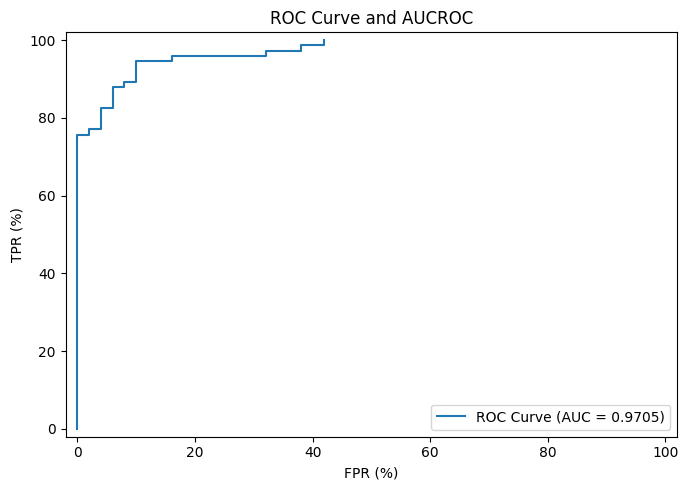

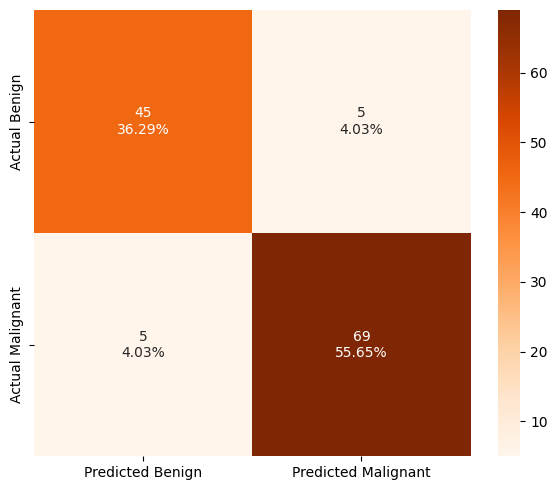

{'acc': np.float64(0.9193548387096774), 'tpr': np.float64(0.9324324324324325), 'fpr': np.float64(0.1), 'precision': np.float64(0.9324324324324325), 'f1-score': np.float64(0.9324324324324325)}

--- GAN | Teste ---


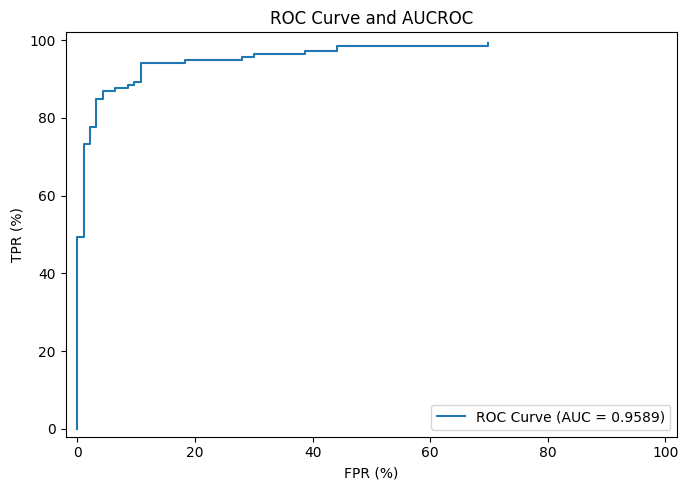

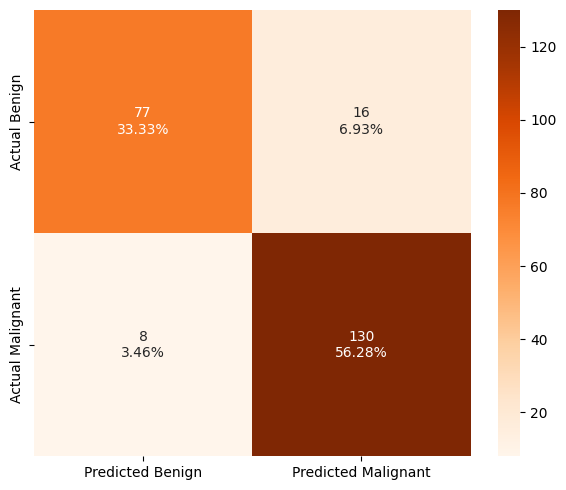

{'acc': np.float64(0.8961038961038961), 'tpr': np.float64(0.9420289855072463), 'fpr': np.float64(0.17204301075268819), 'precision': np.float64(0.8904109589041096), 'f1-score': np.float64(0.9154929577464788)}


In [225]:
# ============================================================
# GAN - 5) Avaliação (validação e teste)
# ============================================================
def evaluate_split(name, y_true, scores, threshold):
    print(f"\n--- GAN | {name} ---")
    plot_roc_curve(y_true, scores)
    y_pred = scores > threshold
    plot_confusion_matrix(y_true, y_pred)
    print(get_overall_metrics(y_true, y_pred))


evaluate_split("Validação", y_val, val_scores_gan, BEST_THRESHOLD_GAN)
evaluate_split("Teste", y_test, test_scores_gan, BEST_THRESHOLD_GAN)

In [226]:
# ============================================================
# Configuração, reprodutibilidade e utilitários comuns de avaliação
# ============================================================

def set_global_seed(seed=RANDOM_SEED):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def choose_threshold_youden(y_true, scores):
    fpr, tpr, thresholds = roc_curve(y_true, scores)
    df_roc = pd.DataFrame({"fpr": fpr, "tpr": tpr, "threshold": thresholds})
    df_roc["youden"] = df_roc["tpr"] - df_roc["fpr"]

    best_idx = df_roc["youden"].idxmax()
    best_threshold = df_roc.loc[best_idx, "threshold"]
    return best_threshold, df_roc


def evaluate_anomaly_scores(split_name, y_true, scores, threshold=None, plot=True):
    auc = roc_auc_score(y_true, scores)

    if threshold is None:
        threshold, _ = choose_threshold_youden(y_true, scores)

    y_pred = (scores > threshold).astype(int)
    metrics = get_overall_metrics(y_true, y_pred)

    print(f"\n--- {split_name} ---")
    print(f"AUC-ROC: {auc:.4f}")
    print(f"Threshold: {threshold:.6f}")
    print(metrics)

    if plot:
        plot_roc_curve(y_true, scores)
        plot_confusion_matrix(y_true, y_pred)

    return {"auc": auc, "threshold": threshold, **metrics}


# Aplica configuração de seed uma vez no início da célula
set_global_seed(RANDOM_SEED)
print(f"Seed global configurada: {RANDOM_SEED}")
print(f"Device ativo: {device}")

Seed global configurada: 33
Device ativo: cpu


In [227]:
from sklearn.preprocessing import MinMaxScaler

# ============================================================
# Comparação e Padronização de Scores entre Modelos
# ============================================================

# Compilar scores de todos os modelos
scores_comparison = pd.DataFrame({
    'KMeans': val_anomaly_scores,
    'IForest': val_scores_iforest,
    'GAN': val_scores_gan,
    'True_Label': y_val.values
})

print("Estatísticas dos scores de validação:")
print(scores_comparison[['KMeans', 'IForest', 'GAN']].describe().round(4))

# Normalizar scores para escala [0, 1] para comparação justa

scaler_scores = MinMaxScaler()
scores_normalized = scaler_scores.fit_transform(scores_comparison[['KMeans', 'IForest', 'GAN']])

scores_comparison_norm = pd.DataFrame({
    'KMeans': scores_normalized[:, 0],
    'IForest': scores_normalized[:, 1],
    'GAN': scores_normalized[:, 2],
    'True_Label': y_val.values
})

print("\nEstatísticas dos scores normalizados:")
print(scores_comparison_norm[['KMeans', 'IForest', 'GAN']].describe().round(4))

# Comparar AUC-ROC de cada modelo
print("\n--- Comparação de AUC-ROC (Validação) ---")
auc_kmeans = roc_auc_score(y_val, val_anomaly_scores)
auc_iforest = roc_auc_score(y_val, val_scores_iforest)
auc_gan = roc_auc_score(y_val, val_scores_gan)

print(f"KMeans:    {auc_kmeans:.4f}")
print(f"IForest:   {auc_iforest:.4f}")
print(f"GAN:       {auc_gan:.4f}")

# Predições binárias com thresholds otimizados
predictions_val = pd.DataFrame({
    'KMeans': (val_anomaly_scores > BEST_VALIDATION_THRESHOLD).astype(int),
    'IForest': (val_scores_iforest > BEST_THRESHOLD_IFOREST).astype(int),
    'GAN': (val_scores_gan > BEST_THRESHOLD_GAN).astype(int),
    'True_Label': y_val.values
})

print("\n--- Comparação de Métricas (Validação) ---")
for model in ['KMeans', 'IForest', 'GAN']:
    metrics = get_overall_metrics(y_val, predictions_val[model])
    print(f"\n{model}:")
    for key, val in metrics.items():
        print(f"  {key}: {val:.4f}")

# Teste com os mesmos thresholds
predictions_test = pd.DataFrame({
    'KMeans': (test_anomaly_scores > BEST_VALIDATION_THRESHOLD).astype(int),
    'IForest': (test_scores_iforest > BEST_THRESHOLD_IFOREST).astype(int),
    'GAN': (test_scores_gan > BEST_THRESHOLD_GAN).astype(int),
    'True_Label': y_test.values
})

print("\n--- Comparação de métricas (Teste) ---")
for model in ['KMeans', 'IForest', 'GAN']:
    metrics = get_overall_metrics(y_test, predictions_test[model])
    print(f"\n{model}:")
    for key, val in metrics.items():
        print(f"  {key}: {val:.4f}")

Estatísticas dos scores de validação:
         KMeans   IForest       GAN
count  124.0000  124.0000  124.0000
mean     1.3618    0.0166    0.5870
std      0.9413    0.0989    0.1523
min      0.2778   -0.1460    0.2619
25%      0.6588   -0.0662    0.4634
50%      1.0574    0.0067    0.5680
75%      1.8848    0.1024    0.7055
max      4.9311    0.2287    0.8801

Estatísticas dos scores normalizados:
         KMeans   IForest       GAN
count  124.0000  124.0000  124.0000
mean     0.2330    0.4338    0.5258
std      0.2023    0.2640    0.2464
min      0.0000    0.0000    0.0000
25%      0.0819    0.2129    0.3259
50%      0.1675    0.4075    0.4950
75%      0.3453    0.6629    0.7174
max      1.0000    1.0000    1.0000

--- Comparação de AUC-ROC (Validação) ---
KMeans:    0.9481
IForest:   0.9465
GAN:       0.9705

--- Comparação de Métricas (Validação) ---

KMeans:
  acc: 0.8871
  tpr: 0.8514
  fpr: 0.0600
  precision: 0.9545
  f1-score: 0.9000

IForest:
  acc: 0.9194
  tpr: 0.9730
  fpr:

In [228]:
# Métricas principais com intervalo de confiança (bootstrap)

def _binary_metrics(y_true, y_pred, y_score=None):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    acc = (tp + tn) / (tp + tn + fp + fn)
    tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    f1 = (2 * precision * tpr / (precision + tpr)) if (precision + tpr) > 0 else np.nan

    out = {
        "acc": acc,
        "tpr": tpr,
        "fpr": fpr,
        "precision": precision,
        "f1-score": f1
    }

    if y_score is not None and len(np.unique(y_true)) == 2:
        out["auc"] = roc_auc_score(y_true, y_score)
    elif y_score is not None:
        out["auc"] = np.nan

    return out


def bootstrap_ci_metrics(y_true, y_pred, y_score=None, n_boot=2000, ci=95, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_score = None if y_score is None else np.asarray(y_score)

    point = _binary_metrics(y_true, y_pred, y_score=y_score)
    boot_values = {k: [] for k in point.keys()}

    n = len(y_true)
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)  # amostragem com reposição
        yt = y_true[idx]
        yp = y_pred[idx]
        ys = None if y_score is None else y_score[idx]

        m = _binary_metrics(yt, yp, y_score=ys)
        for k, v in m.items():
            if not np.isnan(v):
                boot_values[k].append(v)

    alpha = (100 - ci) / 2
    rows = []
    for metric, point_val in point.items():
        vals = np.array(boot_values[metric], dtype=float)
        low = np.percentile(vals, alpha) if len(vals) > 0 else np.nan
        high = np.percentile(vals, 100 - alpha) if len(vals) > 0 else np.nan
        rows.append({
            "metric": metric,
            "point_estimate": point_val,
            f"ci_{alpha:.1f}%": low,
            f"ci_{100-alpha:.1f}%": high
        })

    return pd.DataFrame(rows)


def summarize_models_with_bootstrap(y_true, pred_dict, score_dict=None, split_name="Split", n_boot=2000, ci=95):
    all_tables = []
    for model_name, y_pred in pred_dict.items():
        y_score = None if score_dict is None else score_dict.get(model_name, None)
        table = bootstrap_ci_metrics(
            y_true=y_true,
            y_pred=y_pred,
            y_score=y_score,
            n_boot=n_boot,
            ci=ci,
            seed=RANDOM_SEED
        )
        table.insert(0, "model", model_name)
        all_tables.append(table)

    result = pd.concat(all_tables, ignore_index=True)
    print(f"\n=== {split_name} | Bootstrap CI ({ci}%) ===")
    display(result)
    return result


# ---- Validação ----
pred_val_dict = {
    "KMeans": predictions_val["KMeans"].values,
    "IForest": predictions_val["IForest"].values,
    "GAN": predictions_val["GAN"].values
}
score_val_dict = {
    "KMeans": val_anomaly_scores,
    "IForest": val_scores_iforest,
    "GAN": val_scores_gan
}

val_bootstrap_results = summarize_models_with_bootstrap(
    y_true=y_val.values,
    pred_dict=pred_val_dict,
    score_dict=score_val_dict,
    split_name="Validação",
    n_boot=2000,
    ci=95
)

# ---- Teste ----
pred_test_dict = {
    "KMeans": predictions_test["KMeans"].values,
    "IForest": predictions_test["IForest"].values,
    "GAN": predictions_test["GAN"].values
}
score_test_dict = {
    "KMeans": test_anomaly_scores,
    "IForest": test_scores_iforest,
    "GAN": test_scores_gan
}

test_bootstrap_results = summarize_models_with_bootstrap(
    y_true=y_test.values,
    pred_dict=pred_test_dict,
    score_dict=score_test_dict,
    split_name="Teste",
    n_boot=2000,
    ci=95
)


=== Validação | Bootstrap CI (95%) ===


,model,metric,point_estimate,ci_2.5%,ci_97.5%
0,KMeans,acc,0.887097,0.822581,0.935484
1,KMeans,tpr,0.851351,0.762485,0.926471
2,KMeans,fpr,0.060000,0.000000,0.132107
3,KMeans,precision,0.954545,0.895522,1.000000
4,KMeans,f1-score,0.900000,0.839681,0.945946
5,KMeans,auc,0.948108,0.905616,0.979972
6,IForest,acc,0.919355,0.870968,0.959677
7,IForest,tpr,0.972973,0.929391,1.000000
8,IForest,fpr,0.160000,0.063797,0.269231
9,IForest,precision,0.900000,0.828903,0.961538



=== Teste | Bootstrap CI (95%) ===


,model,metric,point_estimate,ci_2.5%,ci_97.5%
0,KMeans,acc,0.922078,0.887446,0.956710
1,KMeans,tpr,0.891304,0.835935,0.938931
2,KMeans,fpr,0.032258,0.000000,0.073171
3,KMeans,precision,0.976190,0.946426,1.000000
4,KMeans,f1-score,0.931818,0.898296,0.960703
5,KMeans,auc,0.974365,0.955657,0.989314
6,IForest,acc,0.913420,0.874459,0.948052
7,IForest,tpr,0.963768,0.928058,0.992368
8,IForest,fpr,0.161290,0.086538,0.238636
9,IForest,precision,0.898649,0.847819,0.946318


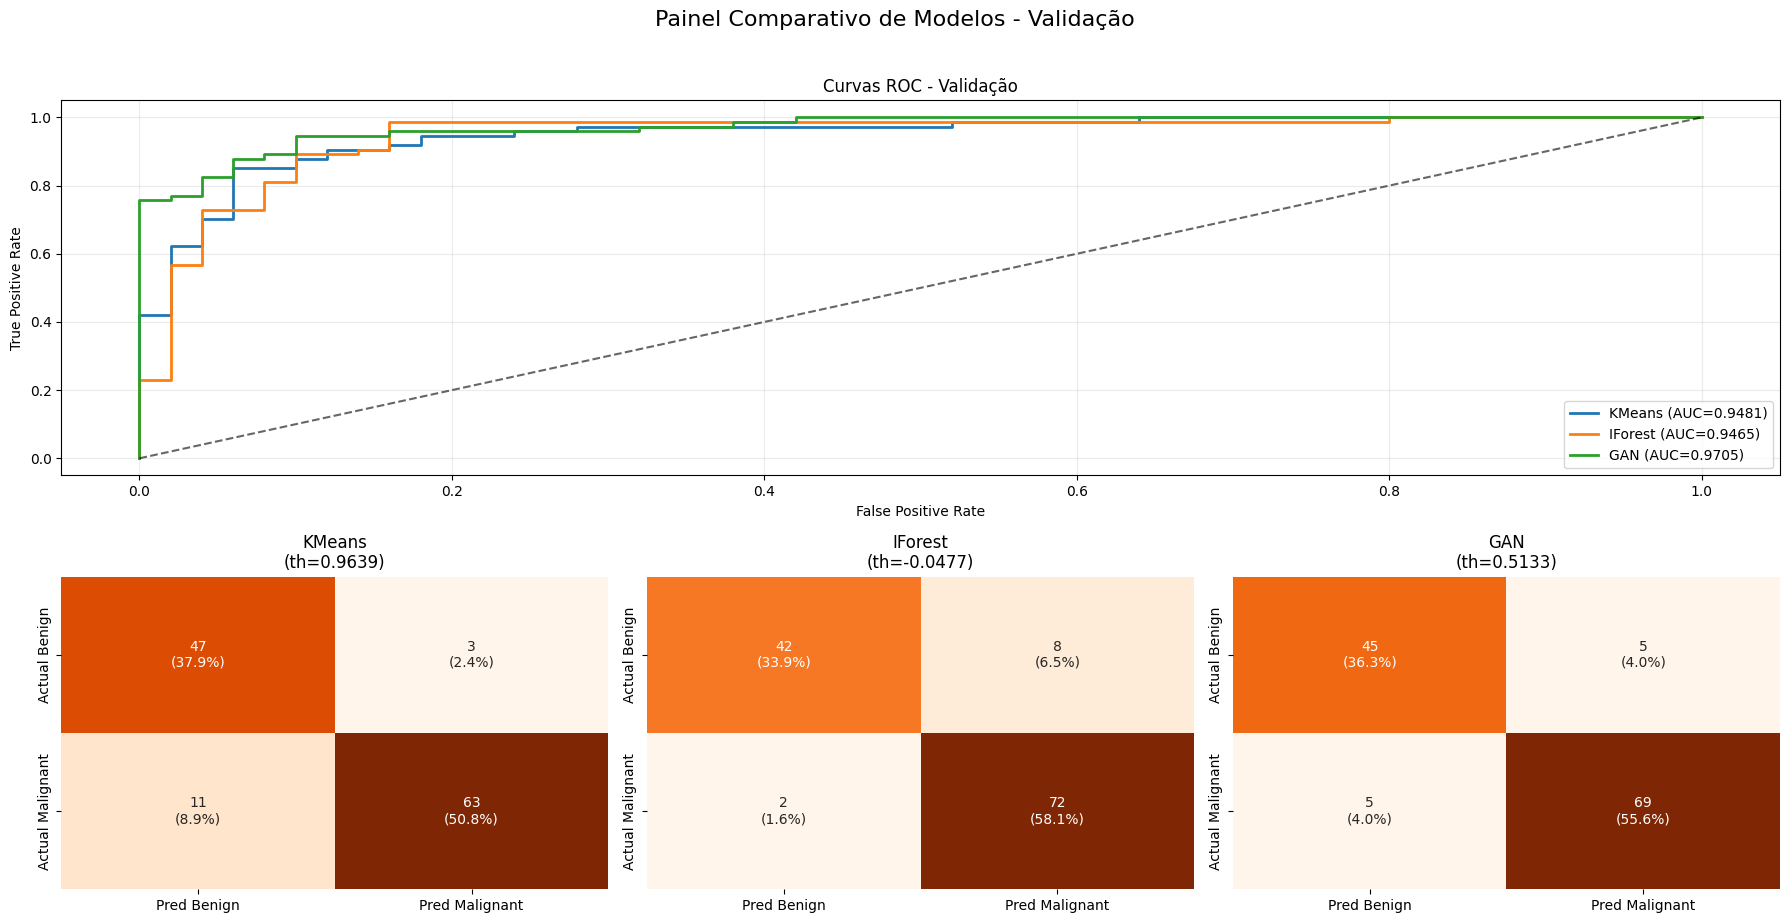

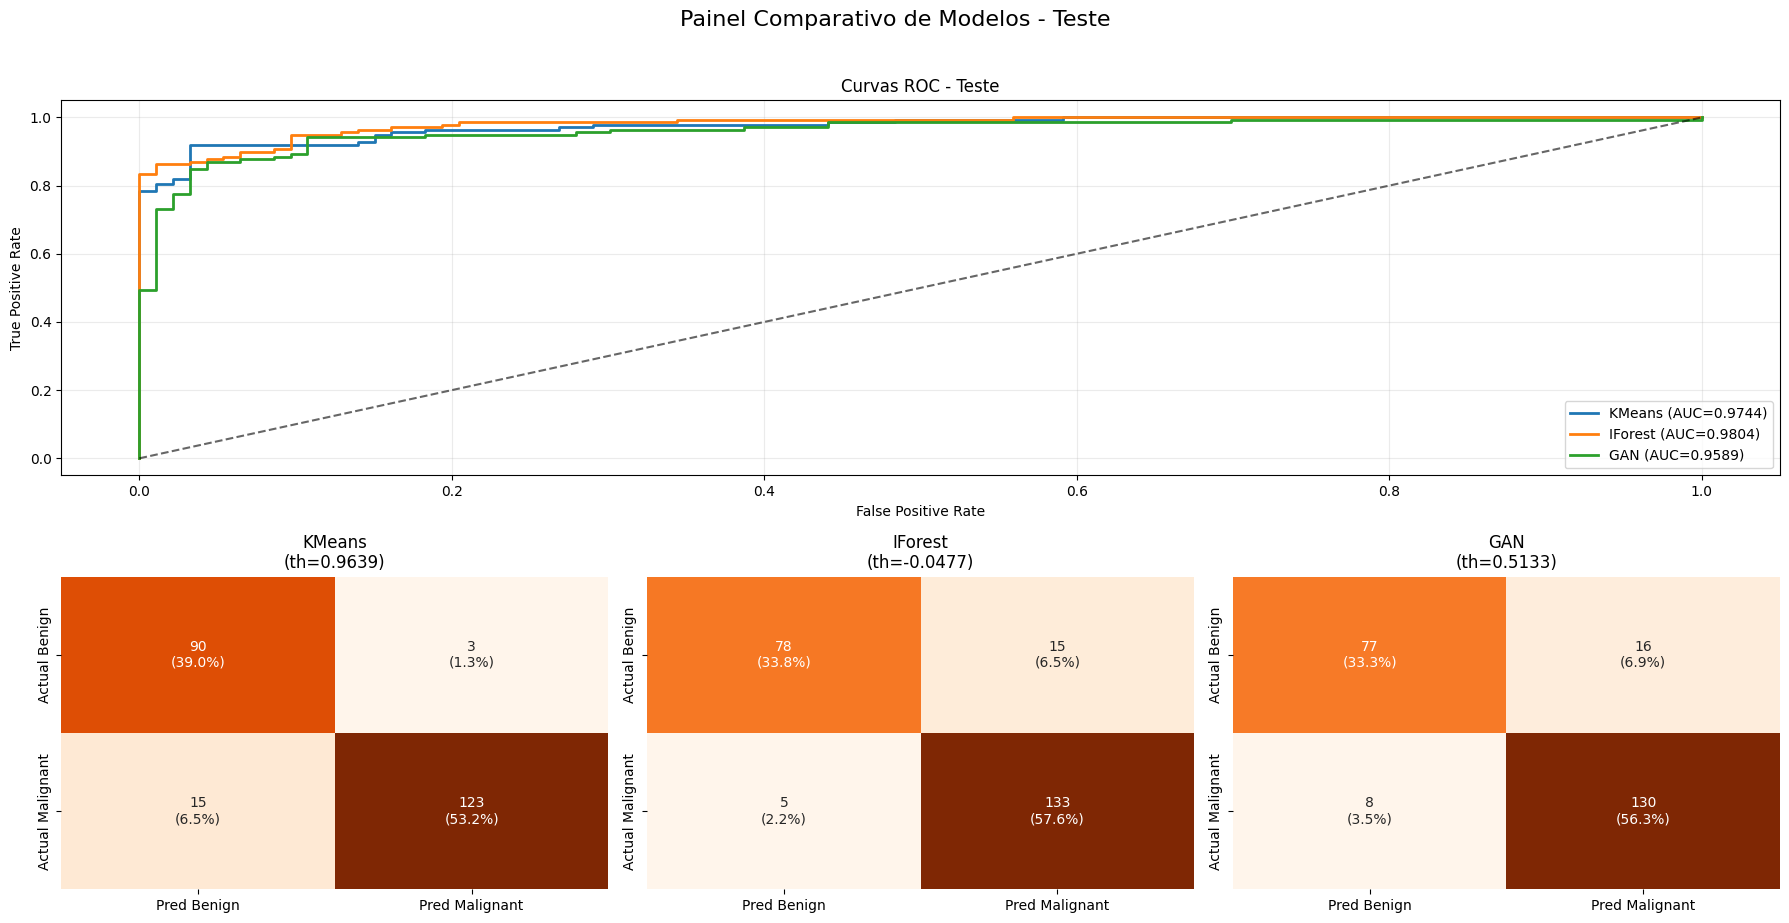

In [229]:
# Painel único comparativo: ROC + AUC + matrizes de confusão (Validação e Teste)

def plot_comparative_panel(y_true, score_dict, threshold_dict, split_name="Split"):
    y_true_np = np.asarray(y_true)

    fig = plt.figure(figsize=(18, 9))
    gs = fig.add_gridspec(2, 3, height_ratios=[1.2, 1])

    # --- ROC comparativa ---
    ax_roc = fig.add_subplot(gs[0, :])
    for model_name, scores in score_dict.items():
        fpr, tpr, _ = roc_curve(y_true_np, scores)
        auc = roc_auc_score(y_true_np, scores)
        ax_roc.plot(fpr, tpr, lw=2, label=f"{model_name} (AUC={auc:.4f})")

    ax_roc.plot([0, 1], [0, 1], "k--", alpha=0.6)
    ax_roc.set_title(f"Curvas ROC - {split_name}")
    ax_roc.set_xlabel("False Positive Rate")
    ax_roc.set_ylabel("True Positive Rate")
    ax_roc.grid(alpha=0.25)
    ax_roc.legend(loc="lower right")

    # --- Matrizes de confusão ---
    for i, (model_name, scores) in enumerate(score_dict.items()):
        ax_cm = fig.add_subplot(gs[1, i])
        threshold = threshold_dict[model_name]
        y_pred = (scores > threshold).astype(int)

        cm = confusion_matrix(y_true_np, y_pred, labels=[0, 1])
        cm_pct = cm / cm.sum()

        labels = np.array([
            f"{cm[0,0]}\n({cm_pct[0,0]*100:.1f}%)",
            f"{cm[0,1]}\n({cm_pct[0,1]*100:.1f}%)",
            f"{cm[1,0]}\n({cm_pct[1,0]*100:.1f}%)",
            f"{cm[1,1]}\n({cm_pct[1,1]*100:.1f}%)"
        ]).reshape(2, 2)

        sns.heatmap(
            cm,
            annot=labels,
            fmt="",
            cmap="Oranges",
            cbar=False,
            ax=ax_cm,
            xticklabels=["Pred Benign", "Pred Malignant"],
            yticklabels=["Actual Benign", "Actual Malignant"]
        )
        ax_cm.set_title(f"{model_name}\n(th={threshold:.4f})")

    plt.suptitle(f"Painel Comparativo de Modelos - {split_name}", y=1.02, fontsize=16)
    plt.tight_layout()
    plt.show()


thresholds_models = {
    "KMeans": BEST_VALIDATION_THRESHOLD,
    "IForest": BEST_THRESHOLD_IFOREST,
    "GAN": BEST_THRESHOLD_GAN
}

scores_val_models = {
    "KMeans": val_anomaly_scores,
    "IForest": val_scores_iforest,
    "GAN": val_scores_gan
}

scores_test_models = {
    "KMeans": test_anomaly_scores,
    "IForest": test_scores_iforest,
    "GAN": test_scores_gan
}

plot_comparative_panel(y_val, scores_val_models, thresholds_models, split_name="Validação")
plot_comparative_panel(y_test, scores_test_models, thresholds_models, split_name="Teste")

In [230]:
# Sensibilidade de threshold: Youden vs alvo de FPR (validação -> aplicado no teste)

def choose_threshold_target_fpr(y_true, scores, target_fpr=0.05):
    fpr, tpr, thresholds = roc_curve(y_true, scores)
    valid_idx = np.where(fpr <= target_fpr)[0]

    if len(valid_idx) == 0:
        best_idx = np.argmin(np.abs(fpr - target_fpr))
    else:
        # maior TPR mantendo FPR <= alvo
        best_idx = valid_idx[np.argmax(tpr[valid_idx])]

    return thresholds[best_idx], fpr[best_idx], tpr[best_idx]


models_val_scores = {
    "KMeans": val_anomaly_scores,
    "IForest": val_scores_iforest,
    "GAN": val_scores_gan
}

models_test_scores = {
    "KMeans": test_anomaly_scores,
    "IForest": test_scores_iforest,
    "GAN": test_scores_gan
}

fpr_targets = [0.01, 0.03, 0.05, 0.10]
rows = []

for model_name in models_val_scores:
    val_scores = models_val_scores[model_name]
    test_scores = models_test_scores[model_name]

    # Threshold por Youden
    th_youden, _ = choose_threshold_youden(y_val, val_scores)
    pred_val_y = (val_scores > th_youden).astype(int)
    pred_test_y = (test_scores > th_youden).astype(int)

    m_val_y = get_overall_metrics(y_val, pred_val_y)
    m_test_y = get_overall_metrics(y_test, pred_test_y)

    rows.append({
        "model": model_name,
        "strategy": "Youden",
        "target_fpr": np.nan,
        "threshold": th_youden,
        "val_auc": roc_auc_score(y_val, val_scores),
        "val_acc": m_val_y["acc"], "val_tpr": m_val_y["tpr"], "val_fpr": m_val_y["fpr"], "val_f1": m_val_y["f1-score"],
        "test_auc": roc_auc_score(y_test, test_scores),
        "test_acc": m_test_y["acc"], "test_tpr": m_test_y["tpr"], "test_fpr": m_test_y["fpr"], "test_f1": m_test_y["f1-score"],
    })

    # Threshold por alvo de FPR (estimado na validação)
    for target in fpr_targets:
        th_fpr, fpr_val_at_th, tpr_val_at_th = choose_threshold_target_fpr(y_val, val_scores, target_fpr=target)

        pred_val_f = (val_scores > th_fpr).astype(int)
        pred_test_f = (test_scores > th_fpr).astype(int)

        m_val_f = get_overall_metrics(y_val, pred_val_f)
        m_test_f = get_overall_metrics(y_test, pred_test_f)

        rows.append({
            "model": model_name,
            "strategy": "Target_FPR",
            "target_fpr": target,
            "threshold": th_fpr,
            "val_auc": roc_auc_score(y_val, val_scores),
            "val_acc": m_val_f["acc"], "val_tpr": m_val_f["tpr"], "val_fpr": m_val_f["fpr"], "val_f1": m_val_f["f1-score"],
            "test_auc": roc_auc_score(y_test, test_scores),
            "test_acc": m_test_f["acc"], "test_tpr": m_test_f["tpr"], "test_fpr": m_test_f["fpr"], "test_f1": m_test_f["f1-score"],
            "val_fpr_at_selected_th": fpr_val_at_th,
            "val_tpr_at_selected_th": tpr_val_at_th,
        })

threshold_sensitivity_df = pd.DataFrame(rows)

print("Resumo completo:")
display(threshold_sensitivity_df.sort_values(["model", "strategy", "target_fpr"]).round(4))

print("\nComparação rápida (Teste): TPR vs FPR")
display(
    threshold_sensitivity_df[
        ["model", "strategy", "target_fpr", "threshold", "test_tpr", "test_fpr", "test_f1", "test_acc"]
    ].sort_values(["model", "strategy", "target_fpr"]).round(4)
)

Resumo completo:


,model,strategy,target_fpr,threshold,val_auc,val_acc,val_tpr,val_fpr,val_f1,test_auc,test_acc,test_tpr,test_fpr,test_f1,val_fpr_at_selected_th,val_tpr_at_selected_th
11,GAN,Target_FPR,0.01,0.6075,0.9705,0.8468,0.7432,0.00,0.8527,0.9589,0.8571,0.7754,0.0215,0.8664,0.00,0.7568
12,GAN,Target_FPR,0.03,0.6038,0.9705,0.8468,0.7568,0.02,0.8550,0.9589,0.8571,0.7754,0.0215,0.8664,0.02,0.7703
13,GAN,Target_FPR,0.05,0.5633,0.9705,0.8710,0.8108,0.04,0.8824,0.9589,0.9048,0.8696,0.0430,0.9160,0.04,0.8243
14,GAN,Target_FPR,0.10,0.5133,0.9705,0.9194,0.9324,0.10,0.9324,0.9589,0.8961,0.9420,0.1720,0.9155,0.10,0.9459
10,GAN,Youden,NaN,0.5133,0.9705,0.9194,0.9324,0.10,0.9324,0.9589,0.8961,0.9420,0.1720,0.9155,NaN,NaN
6,IForest,Target_FPR,0.01,0.1370,0.9465,0.5323,0.2162,0.00,0.3556,0.9804,0.4978,0.1594,0.0000,0.2750,0.00,0.2297
7,IForest,Target_FPR,0.03,0.0719,0.9465,0.7258,0.5541,0.02,0.7069,0.9804,0.7749,0.6232,0.0000,0.7679,0.02,0.5676
8,IForest,Target_FPR,0.05,0.0340,0.9465,0.8145,0.7162,0.04,0.8217,0.9804,0.8701,0.7826,0.0000,0.8780,0.04,0.7297
9,IForest,Target_FPR,0.10,-0.0229,0.9465,0.8871,0.8784,0.10,0.9028,0.9804,0.9091,0.9130,0.0968,0.9231,0.10,0.8919
5,IForest,Youden,NaN,-0.0477,0.9465,0.9194,0.9730,0.16,0.9351,0.9804,0.9134,0.9638,0.1613,0.9301,NaN,NaN



Comparação rápida (Teste): TPR vs FPR


,model,strategy,target_fpr,threshold,test_tpr,test_fpr,test_f1,test_acc
11,GAN,Target_FPR,0.01,0.6075,0.7754,0.0215,0.8664,0.8571
12,GAN,Target_FPR,0.03,0.6038,0.7754,0.0215,0.8664,0.8571
13,GAN,Target_FPR,0.05,0.5633,0.8696,0.0430,0.9160,0.9048
14,GAN,Target_FPR,0.10,0.5133,0.9420,0.1720,0.9155,0.8961
10,GAN,Youden,NaN,0.5133,0.9420,0.1720,0.9155,0.8961
6,IForest,Target_FPR,0.01,0.1370,0.1594,0.0000,0.2750,0.4978
7,IForest,Target_FPR,0.03,0.0719,0.6232,0.0000,0.7679,0.7749
8,IForest,Target_FPR,0.05,0.0340,0.7826,0.0000,0.8780,0.8701
9,IForest,Target_FPR,0.10,-0.0229,0.9130,0.0968,0.9231,0.9091
5,IForest,Youden,NaN,-0.0477,0.9638,0.1613,0.9301,0.9134


In [231]:
# Inspeção de erros (FP/FN) com amostras e features explicativas

def inspect_fp_fn(
    model_name,
    X_split,
    y_true,
    scores,
    threshold,
    ref_df,
    top_k_features=5,
    max_samples=10
):
    y_true_np = np.asarray(y_true).astype(int)
    y_pred = (np.asarray(scores) > float(threshold)).astype(int)

    fp_idx = np.where((y_true_np == 0) & (y_pred == 1))[0]
    fn_idx = np.where((y_true_np == 1) & (y_pred == 0))[0]

    ref_mean = ref_df.mean()
    ref_std = ref_df.std().replace(0, 1e-8)

    def build_table(indexes, error_type):
        rows = []
        for idx in indexes[:max_samples]:
            x = X_split.iloc[idx]
            z_abs = ((x - ref_mean) / ref_std).abs().sort_values(ascending=False).head(top_k_features)

            top_feats = " | ".join([
                f"{feat}: val={x[feat]:.4f}, z={z_abs[feat]:.2f}"
                for feat in z_abs.index
            ])

            rows.append({
                "idx_split": int(idx),
                "erro": error_type,
                "y_true": int(y_true_np[idx]),
                "y_pred": int(y_pred[idx]),
                "score": float(scores[idx]),
                "threshold": float(threshold),
                "top_features": top_feats
            })
        return pd.DataFrame(rows)

    fp_table = build_table(fp_idx, "FP")
    fn_table = build_table(fn_idx, "FN")

    print(f"\n=== {model_name} | Inspeção de Erros ===")
    print(f"FP: {len(fp_idx)} | FN: {len(fn_idx)} | Total erros: {len(fp_idx) + len(fn_idx)}")

    if not fp_table.empty:
        print("\n--- Amostras FP ---")
        display(fp_table)
    else:
        print("\n--- Amostras FP ---")
        print("Sem falsos positivos.")

    if not fn_table.empty:
        print("\n--- Amostras FN ---")
        display(fn_table)
    else:
        print("\n--- Amostras FN ---")
        print("Sem falsos negativos.")

    return fp_table, fn_table


# Escolhe automaticamente o melhor modelo pela AUC na validação
val_auc_by_model = {
    "KMeans": roc_auc_score(y_val, val_anomaly_scores),
    "IForest": roc_auc_score(y_val, val_scores_iforest),
    "GAN": roc_auc_score(y_val, val_scores_gan),
}
best_model_name = max(val_auc_by_model, key=val_auc_by_model.get)

scores_test_by_model = {
    "KMeans": test_anomaly_scores,
    "IForest": test_scores_iforest,
    "GAN": test_scores_gan,
}
threshold_by_model = {
    "KMeans": BEST_VALIDATION_THRESHOLD,
    "IForest": BEST_THRESHOLD_IFOREST,
    "GAN": BEST_THRESHOLD_GAN,
}

print("AUC validação por modelo:", {k: round(v, 4) for k, v in val_auc_by_model.items()})
print("Modelo selecionado:", best_model_name)

fp_samples, fn_samples = inspect_fp_fn(
    model_name=best_model_name,
    X_split=X_test,          # features em escala original (pós seleção de features)
    y_true=y_test,
    scores=scores_test_by_model[best_model_name],
    threshold=threshold_by_model[best_model_name],
    ref_df=X_train,          # referência de normalidade (benignos de treino)
    top_k_features=5,
    max_samples=10
)

AUC validação por modelo: {'KMeans': np.float64(0.9481), 'IForest': np.float64(0.9465), 'GAN': np.float64(0.9705)}
Modelo selecionado: GAN

=== GAN | Inspeção de Erros ===
FP: 16 | FN: 8 | Total erros: 24

--- Amostras FP ---


,idx_split,erro,y_true,y_pred,score,threshold,top_features
0,14,FP,0,1,0.529554,0.513329,"smoothness1: val=0.1092, z=1.19 | texture2: va..."
1,40,FP,0,1,0.626080,0.513329,"concave_points1: val=0.0706, z=2.73 | area2: v..."
2,68,FP,0,1,0.600040,0.513329,"symmetry3: val=0.4128, z=3.39 | compactness3: ..."
3,75,FP,0,1,0.555705,0.513329,"concave_points1: val=0.0853, z=3.61 | compactn..."
4,117,FP,0,1,0.549764,0.513329,"smoothness1: val=0.1134, z=1.49 | smoothness3:..."
5,126,FP,0,1,0.521362,0.513329,"fractal_dimension1: val=0.0784, z=2.15 | fract..."
6,127,FP,0,1,0.562191,0.513329,"area3: val=922.8000, z=2.31 | concave_points1:..."
7,133,FP,0,1,0.515404,0.513329,"area3: val=867.1000, z=1.96 | concave_points3:..."
8,135,FP,0,1,0.518870,0.513329,"symmetry3: val=0.3313, z=1.44 | texture2: val=..."
9,151,FP,0,1,0.555695,0.513329,"area3: val=1009.0000, z=2.84 | concave_points1..."



--- Amostras FN ---


,idx_split,erro,y_true,y_pred,score,threshold,top_features
0,10,FN,1,0,0.485254,0.513329,"texture1: val=29.8100, z=2.82 | area2: val=45...."
1,58,FN,1,0,0.278478,0.513329,"smoothness2: val=0.0311, z=7.46 | concave_poin..."
2,98,FN,1,0,0.508927,0.513329,"concave_points1: val=0.0919, z=4.01 | concavit..."
3,110,FN,1,0,0.452579,0.513329,"area2: val=106.0000, z=9.05 | radius2: val=1.2..."
4,111,FN,1,0,0.487152,0.513329,"compactness3: val=0.7090, z=5.54 | concavity3:..."
5,154,FN,1,0,0.465860,0.513329,"area2: val=38.8700, z=1.86 | area3: val=808.90..."
6,187,FN,1,0,0.454772,0.513329,"area3: val=787.9000, z=1.47 | smoothness2: val..."
7,207,FN,1,0,0.412658,0.513329,"area3: val=876.5000, z=2.02 | concave_points1:..."


In [232]:
# ============================================================
# Tabela Final Consolidada e Ranking de Modelos
# ============================================================

# Consolidar resultados de validação e teste
results_summary = []

for model_name in ["KMeans", "IForest", "GAN"]:
    val_scores = {
        "KMeans": val_anomaly_scores,
        "IForest": val_scores_iforest,
        "GAN": val_scores_gan
    }[model_name]
    
    test_scores = {
        "KMeans": test_anomaly_scores,
        "IForest": test_scores_iforest,
        "GAN": test_scores_gan
    }[model_name]
    
    threshold = {
        "KMeans": BEST_VALIDATION_THRESHOLD,
        "IForest": BEST_THRESHOLD_IFOREST,
        "GAN": BEST_THRESHOLD_GAN
    }[model_name]
    
    # Validação
    val_auc = roc_auc_score(y_val, val_scores)
    val_pred = (val_scores > threshold).astype(int)
    val_metrics = get_overall_metrics(y_val, val_pred)
    
    # Teste
    test_auc = roc_auc_score(y_test, test_scores)
    test_pred = (test_scores > threshold).astype(int)
    test_metrics = get_overall_metrics(y_test, test_pred)
    
    results_summary.append({
        "Modelo": model_name,
        "Threshold": f"{threshold:.6f}",
        "Val_AUC": f"{val_auc:.4f}",
        "Val_Acurácia": f"{val_metrics['acc']:.4f}",
        "Val_Sensibilidade": f"{val_metrics['tpr']:.4f}",
        "Val_Especificidade": f"{1 - val_metrics['fpr']:.4f}",
        "Val_F1": f"{val_metrics['f1-score']:.4f}",
        "Test_AUC": f"{test_auc:.4f}",
        "Test_Acurácia": f"{test_metrics['acc']:.4f}",
        "Test_Sensibilidade": f"{test_metrics['tpr']:.4f}",
        "Test_Especificidade": f"{1 - test_metrics['fpr']:.4f}",
        "Test_F1": f"{test_metrics['f1-score']:.4f}",
    })

df_results_final = pd.DataFrame(results_summary)

print("\n=== TABELA FINAL CONSOLIDADA ===\n")
display(df_results_final)

# Ranking por AUC no Teste
print("\n=== RANKING DE MODELOS (Teste - AUC) ===\n")
auc_test_scores = [
    (roc_auc_score(y_test, test_anomaly_scores), "KMeans"),
    (roc_auc_score(y_test, test_scores_iforest), "IForest"),
    (roc_auc_score(y_test, test_scores_gan), "GAN"),
]
auc_test_scores.sort(reverse=True)

for rank, (auc, model) in enumerate(auc_test_scores, 1):
    print(f"{rank}º lugar: {model:10s} | AUC = {auc:.4f}")

# Ranking por F1 no Teste
print("\n=== RANKING DE MODELOS (Teste - F1-Score) ===\n")

f1_test_scores = []
for model_name in ["KMeans", "IForest", "GAN"]:
    test_scores = {
        "KMeans": test_anomaly_scores,
        "IForest": test_scores_iforest,
        "GAN": test_scores_gan
    }[model_name]
    
    threshold = {
        "KMeans": BEST_VALIDATION_THRESHOLD,
        "IForest": BEST_THRESHOLD_IFOREST,
        "GAN": BEST_THRESHOLD_GAN
    }[model_name]
    
    test_pred = (test_scores > threshold).astype(int)
    test_metrics = get_overall_metrics(y_test, test_pred)
    f1_test_scores.append((test_metrics['f1-score'], model_name))

f1_test_scores.sort(reverse=True)

for rank, (f1, model) in enumerate(f1_test_scores, 1):
    print(f"{rank}º lugar: {model:10s} | F1 = {f1:.4f}")

# Ranking por Acurácia no Teste
print("\n=== RANKING DE MODELOS (Teste - Acurácia) ===\n")

acc_test_scores = []
for model_name in ["KMeans", "IForest", "GAN"]:
    test_scores = {
        "KMeans": test_anomaly_scores,
        "IForest": test_scores_iforest,
        "GAN": test_scores_gan
    }[model_name]
    
    threshold = {
        "KMeans": BEST_VALIDATION_THRESHOLD,
        "IForest": BEST_THRESHOLD_IFOREST,
        "GAN": BEST_THRESHOLD_GAN
    }[model_name]
    
    test_pred = (test_scores > threshold).astype(int)
    test_metrics = get_overall_metrics(y_test, test_pred)
    acc_test_scores.append((test_metrics['acc'], model_name))

acc_test_scores.sort(reverse=True)

for rank, (acc, model) in enumerate(acc_test_scores, 1):
    print(f"{rank}º lugar: {model:10s} | Acurácia = {acc:.4f}")


=== TABELA FINAL CONSOLIDADA ===



,Modelo,Threshold,Val_AUC,Val_Acurácia,Val_Sensibilidade,Val_Especificidade,Val_F1,Test_AUC,Test_Acurácia,Test_Sensibilidade,Test_Especificidade,Test_F1
0,KMeans,0.963865,0.9481,0.8871,0.8514,0.9400,0.9000,0.9744,0.9221,0.8913,0.9677,0.9318
1,IForest,-0.047703,0.9465,0.9194,0.9730,0.8400,0.9351,0.9804,0.9134,0.9638,0.8387,0.9301
2,GAN,0.513329,0.9705,0.9194,0.9324,0.9000,0.9324,0.9589,0.8961,0.9420,0.8280,0.9155



=== RANKING DE MODELOS (Teste - AUC) ===

1º lugar: IForest    | AUC = 0.9804
2º lugar: KMeans     | AUC = 0.9744
3º lugar: GAN        | AUC = 0.9589

=== RANKING DE MODELOS (Teste - F1-Score) ===

1º lugar: KMeans     | F1 = 0.9318
2º lugar: IForest    | F1 = 0.9301
3º lugar: GAN        | F1 = 0.9155

=== RANKING DE MODELOS (Teste - Acurácia) ===

1º lugar: KMeans     | Acurácia = 0.9221
2º lugar: IForest    | Acurácia = 0.9134
3º lugar: GAN        | Acurácia = 0.8961


In [233]:
# ============================================================
# Roteiro de apresentação orientado por evidências (auto-gerado)
# ============================================================

# 1) Consolidar métricas comparáveis entre modelos (Validação e Teste)
model_specs = {
    "KMeans": {
        "val_scores": val_anomaly_scores,
        "test_scores": test_anomaly_scores,
        "threshold": BEST_VALIDATION_THRESHOLD
    },
    "IForest": {
        "val_scores": val_scores_iforest,
        "test_scores": test_scores_iforest,
        "threshold": BEST_THRESHOLD_IFOREST
    },
    "GAN": {
        "val_scores": val_scores_gan,
        "test_scores": test_scores_gan,
        "threshold": BEST_THRESHOLD_GAN
    }
}

rows = []
for model_name, spec in model_specs.items():
    val_pred = (spec["val_scores"] > spec["threshold"]).astype(int)
    test_pred = (spec["test_scores"] > spec["threshold"]).astype(int)

    val_m = get_overall_metrics(y_val, val_pred)
    test_m = get_overall_metrics(y_test, test_pred)

    rows.append({
        "Modelo": model_name,
        "Threshold": float(spec["threshold"]),
        "Val_AUC": float(roc_auc_score(y_val, spec["val_scores"])),
        "Val_F1": float(val_m["f1-score"]),
        "Val_TPR": float(val_m["tpr"]),
        "Val_FPR": float(val_m["fpr"]),
        "Test_AUC": float(roc_auc_score(y_test, spec["test_scores"])),
        "Test_F1": float(test_m["f1-score"]),
        "Test_TPR": float(test_m["tpr"]),
        "Test_FPR": float(test_m["fpr"]),
        "Test_ACC": float(test_m["acc"])
    })

df_evidence = pd.DataFrame(rows).sort_values("Test_AUC", ascending=False).reset_index(drop=True)
best_model = df_evidence.loc[0, "Modelo"]

# 2) Estatísticas do problema/dados
n_total = len(y_clean) if "y_clean" in globals() else len(y)
malignant_rate = float((y_clean.mean() if "y_clean" in globals() else y.mean()) * 100)

n_train = len(X_train) if "X_train" in globals() else np.nan
n_val = len(X_val) if "X_val" in globals() else np.nan
n_test = len(X_test) if "X_test" in globals() else np.nan

val_malignant = float(y_val.mean() * 100)
test_malignant = float(y_test.mean() * 100)

# 3) Evidência adicional (GAN treino), se existir
gan_best_val_auc_txt = ""
if "val_auc_history" in globals() and len(val_auc_history) > 0:
    gan_best_val_auc_txt = f"\n- No treino da GAN, melhor AUC de validação observada: {max(val_auc_history):.4f}."

# 4) Roteiro final
top = df_evidence.iloc[0]
second = df_evidence.iloc[1]

roteiro_apresentacao = f"""
# Roteiro de apresentação (orientado por evidências)

## 1) Contexto e objetivo (30s)
- Problema: detecção de anomalias em câncer de mama (tumores malignos como anomalias).
- Base: {n_total} amostras; taxa de malignos ~ {malignant_rate:.1f}%.
- Objetivo: comparar KMeans, Isolation Forest e GAN usando o mesmo pipeline de avaliação.

## 2) Estratégia metodológica (45s)
- Treino com padrão de normalidade (benignos) e avaliação com benignos + malignos.
- Split utilizado: treino={n_train}, validação={n_val}, teste={n_test}.
- Proporção de malignos: validação={val_malignant:.1f}%, teste={test_malignant:.1f}%.
- Definição de threshold na validação pelo índice de Youden; aplicação fixa no teste.

## 3) Resultados principais (1min)
- Melhor modelo no teste (AUC): **{best_model}**
  - Test AUC={top['Test_AUC']:.4f}, F1={top['Test_F1']:.4f}, TPR={top['Test_TPR']:.4f}, FPR={top['Test_FPR']:.4f}.
- Segundo colocado: **{second['Modelo']}**
  - Test AUC={second['Test_AUC']:.4f}, F1={second['Test_F1']:.4f}.

## 4) Leitura crítica dos resultados (45s)
- AUC compara capacidade de ranqueamento global; F1 resume equilíbrio entre precisão e recall.
- TPR alto favorece sensibilidade clínica; FPR controla alarmes falsos.
- Conclusão prática: priorizar modelo com melhor AUC/F1 mantendo FPR sob controle.

## 5) Conclusão e próximos passos (30s)
- Conclusão: {best_model} apresentou melhor compromisso global no conjunto de teste.
- Próximos passos:
  1. calibração de threshold por meta de FPR clínica;
  2. validação cruzada estratificada;
  3. explicabilidade dos erros (FP/FN) para suporte à decisão.
{gan_best_val_auc_txt}
"""

print("=== Evidências consolidadas ===")
display(df_evidence.round(4))

print("\n=== Roteiro sugerido ===")
print(roteiro_apresentacao)

=== Evidências consolidadas ===


,Modelo,Threshold,Val_AUC,Val_F1,Val_TPR,Val_FPR,Test_AUC,Test_F1,Test_TPR,Test_FPR,Test_ACC
0,IForest,-0.0477,0.9465,0.9351,0.9730,0.16,0.9804,0.9301,0.9638,0.1613,0.9134
1,KMeans,0.9639,0.9481,0.9000,0.8514,0.06,0.9744,0.9318,0.8913,0.0323,0.9221
2,GAN,0.5133,0.9705,0.9324,0.9324,0.10,0.9589,0.9155,0.9420,0.1720,0.8961



=== Roteiro sugerido ===

# Roteiro de apresentação (orientado por evidências)

## 1) Contexto e objetivo (30s)
- Problema: detecção de anomalias em câncer de mama (tumores malignos como anomalias).
- Base: 569 amostras; taxa de malignos ~ 37.3%.
- Objetivo: comparar KMeans, Isolation Forest e GAN usando o mesmo pipeline de avaliação.

## 2) Estratégia metodológica (45s)
- Treino com padrão de normalidade (benignos) e avaliação com benignos + malignos.
- Split utilizado: treino=214, validação=124, teste=231.
- Proporção de malignos: validação=59.7%, teste=59.7%.
- Definição de threshold na validação pelo índice de Youden; aplicação fixa no teste.

## 3) Resultados principais (1min)
- Melhor modelo no teste (AUC): **IForest**
  - Test AUC=0.9804, F1=0.9301, TPR=0.9638, FPR=0.1613.
- Segundo colocado: **KMeans**
  - Test AUC=0.9744, F1=0.9318.

## 4) Leitura crítica dos resultados (45s)
- AUC compara capacidade de ranqueamento global; F1 resume equilíbrio entre precisão e recall.
- TPR 